#### ***Problem Statement***

Beauty company 2021-2025 sales data to identify key revenue and profit drivers accross products, channels, and regions, uncover seasonal trends and outliners, and align performance against bedgets, Use these insights to optimize pricing, promotions and market expansion for sustainable growth and reduced concentration risk.



In [ ]:
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
sheets = pd.read_excel('/content/Sales Dataset.xlsx', sheet_name = None)

In [ ]:
#Assigning dataframes to each sheet

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budgets = sheets['2024 Budgets']


In [ ]:
# Quick look for the size of the data


print(f"dr_sales_shape: {df_sales.shape} ")
print(f"dr_customers_shape: {df_customers.shape} ")
print(f"dr_products_shape: {df_products.shape} ")
print(f"dr_regions_shape: {df_regions.shape} ")
print(f"dr_state_reg_shape: {df_state_reg.shape} ")
print(f"dr_budgets: {df_budgets.shape} ")

dr_sales_shape: (64104, 12) 
dr_customers_shape: (175, 2) 
dr_products_shape: (30, 3) 
dr_regions_shape: (994, 15) 
dr_state_reg_shape: (48, 6) 
dr_budgets: (30, 2) 


In [ ]:
#Quickly look head of all the data

df_sales.head(5)


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2021-01-01 00:00:00,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2021-01-01 00:00:00,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2021-01-01 00:00:00,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2021-01-01 00:00:00,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2021-01-01 00:00:00,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [ ]:
df_budgets.head(5)


,Product Name,2024 Budgets
0,Gentle Foaming Face Cleanser,3016489.209
1,Deep Hydration Face Wash,3050087.565
2,Exfoliating Facial Scrub,2642352.432
3,Micellar Cleansing Water,2885560.824
4,Refreshing Facial Toner,3925424.542


In [ ]:
df_customers.head(5)


,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [ ]:
df_products.head(5)


,Index,Product Name,Quantity
0,1,Gentle Foaming Face Cleanser,150ml
1,2,Deep Hydration Face Wash,200ml
2,3,Exfoliating Facial Scrub,100g
3,4,Micellar Cleansing Water,400ml
4,5,Refreshing Facial Toner,250ml


In [ ]:
df_regions.head(5)


,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [ ]:
df_state_reg.head(5)

,State Code,State,Region,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,AL,Alabama,South,NaN,NaN,NaN
1,AR,Arkansas,South,NaN,NaN,NaN
2,AZ,Arizona,West,NaN,NaN,NaN
3,CA,California,West,NaN,NaN,NaN
4,CO,Colorado,West,NaN,NaN,


In [ ]:
## Null value check for all the tables

df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [ ]:
df_products.isnull().sum()

,0
Index,0
Product Name,0
Quantity,0


In [ ]:
df_budgets.isnull().sum()

,0
Product Name,0
2024 Budgets,0


In [ ]:
df_customers.isnull().sum()

,0
Customer Index,0
Customer Names,0


In [ ]:
df_regions.isnull().sum()

,0
id,0
name,0
county,0
state_code,0
state,0
type,0
latitude,0
longitude,0
area_code,0
population,0


In [ ]:
df_state_reg.isnull().sum()

,0
State Code,0
State,0
Region,0
Unnamed: 3,48
Unnamed: 4,48
Unnamed: 5,47


In [ ]:
#Deleting the null value columns

df_state_reg = df_state_reg.drop(columns=['Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5'])


In [ ]:
df_state_reg.isnull().sum()

,0
State Code,0
State,0
Region,0


#### ***Data Cleaning and Wrangling***

In [ ]:
## Joining the sales data with customer data

df = df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
    )

In [ ]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2021-01-01 00:00:00,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126.0,Rhynoodle Ltd
1,SO - 0003378,2021-01-01 00:00:00,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96.0,Thoughtmix Ltd
2,SO - 0005126,2021-01-01 00:00:00,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8.0,Amerisourc Corp
3,SO - 0005614,2021-01-01 00:00:00,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42.0,Colgate-Pa Group
4,SO - 0005781,2021-01-01 00:00:00,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73.0,Deseret Group


In [ ]:
## Joining the sales data with products

df = df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
    )

In [ ]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name,Quantity
0,SO - 000225,2021-01-01 00:00:00,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126.0,Rhynoodle Ltd,27,Whitening Body Cream,200g
1,SO - 0003378,2021-01-01 00:00:00,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96.0,Thoughtmix Ltd,20,Sunscreen Lotion SPF 30,200ml
2,SO - 0005126,2021-01-01 00:00:00,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8.0,Amerisourc Corp,26,Anti-Cellulite Body Gel,150ml
3,SO - 0005614,2021-01-01 00:00:00,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42.0,Colgate-Pa Group,7,Hyaluronic Acid Serum,50ml
4,SO - 0005781,2021-01-01 00:00:00,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73.0,Deseret Group,8,Retinol Anti-Aging Serum,30ml


In [ ]:
## Joining the sales data with region

df = df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
    )

In [ ]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2021-01-01 00:00:00,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2021-01-01 00:00:00,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2021-01-01 00:00:00,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2021-01-01 00:00:00,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2021-01-01 00:00:00,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [ ]:
## Joining the sales data with state region

df = df.merge(
    df_state_reg[["State Code", "Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code'
    )


In [ ]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2021-01-01 00:00:00,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2021-01-01 00:00:00,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2021-01-01 00:00:00,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2021-01-01 00:00:00,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2021-01-01 00:00:00,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [ ]:
# Merge with 2024 Budgets

df = df.merge(
    df_budgets,
    how='left',
    on='Product Name'
    )

In [ ]:
## Downloading the merged data to identify the duplicate columns


df.to_csv('finalize_sales_data.csv')

In [ ]:
## Cleaning up the redundant columns

# Customer Index
# Index
# id
# state code

cols_to_drop = ['Customer Index', 'Index', 'id', 'State Code']

df = df.drop(columns=cols_to_drop, errors='ignore')
df.head(5)


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2024 Budgets
0,SO - 000225,2021-01-01 00:00:00,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2021-01-01 00:00:00,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2021-01-01 00:00:00,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2021-01-01 00:00:00,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2021-01-01 00:00:00,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [ ]:
 ## Converting all the column names into lower case for easy

 df.columns = df.columns.str.lower()
 df.head(5)

,ordernumber,orderdate,customer name index,channel,currency code,warehouse code,delivery region index,product description index,order quantity,unit price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,region,2024 budgets
0,SO - 000225,2021-01-01 00:00:00,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2021-01-01 00:00:00,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2021-01-01 00:00:00,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2021-01-01 00:00:00,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2021-01-01 00:00:00,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [ ]:
## Displaying the column names

df.columns

Index(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'quantity', 'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households', 'median_income',
       'land_area', 'water_area', 'time_zone', 'region', '2024 budgets'],
      dtype='object')

In [ ]:
# KEEPING THE IMPORTANT COLUMNS WHICH ARE NEEDED FOR THE PROJECT

columns_to_keep = [
    'ordernumber',
    'orderdate',
    'channel',
    'customer names',
    'warehouse code',
    'order quantity',
    'product name',
    'unit price',
    'line total',
    'total unit cost',
    'state_code',
    'county',
    'state',
    'region',
    'latitude',
    'longitude',
    'area_code',
    'type',
    'time_zone',
    '2024 budgets'

    ]



In [ ]:
df = df[columns_to_keep]
df.head(5)

,ordernumber,orderdate,channel,customer names,warehouse code,order quantity,product name,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,area_code,type,time_zone,2024 budgets
0,SO - 000225,2021-01-01 00:00:00,Wholesale,Rhynoodle Ltd,AXW291,6,Whitening Body Cream,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,912,City,America/New York,964940.231
1,SO - 0003378,2021-01-01 00:00:00,Distributor,Thoughtmix Ltd,AXW291,11,Sunscreen Lotion SPF 30,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,317,City,America/Indiana/Indianapolis,2067108.120
2,SO - 0005126,2021-01-01 00:00:00,Wholesale,Amerisourc Corp,AXW291,6,Anti-Cellulite Body Gel,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,925,City,America/Los Angeles,5685138.270
3,SO - 0005614,2021-01-01 00:00:00,Export,Colgate-Pa Group,AXW291,7,Hyaluronic Acid Serum,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,812,City,America/Indiana/Indianapolis,889737.555
4,SO - 0005781,2021-01-01 00:00:00,Wholesale,Deseret Group,AXW291,8,Retinol Anti-Aging Serum,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,959,Town,America/New York,1085037.329


In [ ]:
# Renaming the columns for easier access

df = df.rename(columns={
     'ordernumber' : 'order_number',
    'orderdate' : 'order_date',
    'customer names' : 'customer_names',
    'warehouse code' : 'warehouse_code ',
    'order quantity': 'order_quantity',
    'product name' : 'product_name',
    'unit price': 'unit_price',
    'line total' : 'revenue',# Line total is nothing but revenue
    'total unit cost' : 'total_unit_cost',
    'state_code': 'state_code',
    '2024 budgets' : 'budgets'})

In [ ]:
df.columns

Index(['order_number', 'order_date', 'channel', 'customer_names',
       'warehouse_code ', 'order_quantity', 'product_name', 'unit_price',
       'revenue', 'total_unit_cost', 'state_code', 'county', 'state', 'region',
       'latitude', 'longitude', 'area_code', 'type', 'time_zone', 'budgets'],
      dtype='object')

In [ ]:
## remove the time from the order_date column
## here we have kept the datatype as datetype

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce').dt.normalize()


In [ ]:
# Blanking out all the data which is not in year 2024 orders

df.loc[df['order_date'].dt.year != 2024, 'budgets'] = pd.NA

df.head(5)


,order_number,order_date,channel,customer_names,warehouse_code,order_quantity,product_name,unit_price,revenue,total_unit_cost,state_code,county,state,region,latitude,longitude,area_code,type,time_zone,budgets
0,SO - 000225,2021-01-01,Wholesale,Rhynoodle Ltd,AXW291,6,Whitening Body Cream,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,912,City,America/New York,NaN
1,SO - 0003378,2021-01-01,Distributor,Thoughtmix Ltd,AXW291,11,Sunscreen Lotion SPF 30,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,317,City,America/Indiana/Indianapolis,NaN
2,SO - 0005126,2021-01-01,Wholesale,Amerisourc Corp,AXW291,6,Anti-Cellulite Body Gel,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,925,City,America/Los Angeles,NaN
3,SO - 0005614,2021-01-01,Export,Colgate-Pa Group,AXW291,7,Hyaluronic Acid Serum,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,812,City,America/Indiana/Indianapolis,NaN
4,SO - 0005781,2021-01-01,Wholesale,Deseret Group,AXW291,8,Retinol Anti-Aging Serum,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,959,Town,America/New York,NaN


In [ ]:
# quick check for the data

df.to_csv('final_sales_data.csv')

In [ ]:
# check the datatype for the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64068 non-null  datetime64[ns]
 2   channel          64104 non-null  object        
 3   customer_names   64103 non-null  object        
 4   warehouse_code   64104 non-null  object        
 5   order_quantity   64104 non-null  int64         
 6   product_name     64104 non-null  object        
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   total_unit_cost  64104 non-null  float64       
 10  state_code       64104 non-null  object        
 11  county           64104 non-null  object        
 12  state            64104 non-null  object        
 13  region           64104 non-null  object        
 14  latitude         64104 non-null  float

### ***Feature Engineering***

In [ ]:
## Calculating the Profit

#Revenue = order quantity * unit price -> the data has already calculated

# total cost = order quantity * total unit cost
df['total_cost'] = df['order_quantity'] * df['total_unit_cost']

# profit = Revenue - total cost
df['profit'] = df['revenue'] - df['total_cost']


In [ ]:
# creating a profit margin percentage

df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

df.head(5)

,order_number,order_date,channel,customer_names,warehouse_code,order_quantity,product_name,unit_price,revenue,total_unit_cost,...,region,latitude,longitude,area_code,type,time_zone,budgets,total_cost,profit,profit_margin_pct
0,SO - 000225,2021-01-01,Wholesale,Rhynoodle Ltd,AXW291,6,Whitening Body Cream,2499.1,14994.6,1824.343,...,South,32.08354,-81.09983,912,City,America/New York,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2021-01-01,Distributor,Thoughtmix Ltd,AXW291,11,Sunscreen Lotion SPF 30,2351.7,25868.7,1269.918,...,Midwest,39.61366,-86.10665,317,City,America/Indiana/Indianapolis,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2021-01-01,Wholesale,Amerisourc Corp,AXW291,6,Anti-Cellulite Body Gel,978.2,5869.2,684.740,...,West,37.66243,-121.87468,925,City,America/Los Angeles,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2021-01-01,Export,Colgate-Pa Group,AXW291,7,Hyaluronic Acid Serum,2338.3,16368.1,1028.852,...,Midwest,39.16533,-86.52639,812,City,America/Indiana/Indianapolis,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2021-01-01,Wholesale,Deseret Group,AXW291,8,Retinol Anti-Aging Serum,2291.4,18331.2,1260.270,...,Northeast,41.77524,-72.52443,959,Town,America/New York,NaN,10082.160,8249.040,45.0


### ***Note :***

From the above we can that we have completed the Bussiness understanding, Data understanding, Data collection, Data Preparation/ Data cleaning

Now the next process is EDA, if required we can still go back to the  Data Preparation/ Data cleaning step

### **Explonatory Data Analysis (EDA)**



**Sales Executive**

*1.Total Orders and Revenue (KPI number or bar by month)*

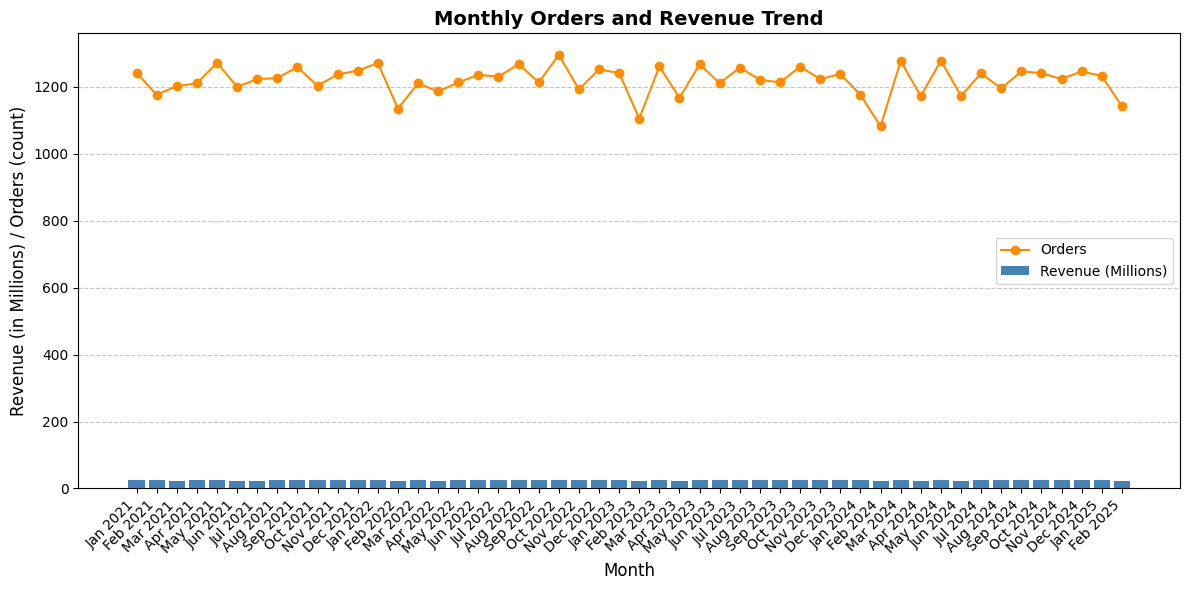

In [ ]:
# Create month-year column
df['order_month'] = df['order_date'].dt.to_period('M')

# Aggregate total orders and revenue by month
monthly_data = df.groupby('order_month').agg({
    'order_number': 'nunique',  # total unique orders per month
    'revenue': 'sum'            # total revenue per month
}).reset_index()

# Convert to readable month names
monthly_data['month_name'] = monthly_data['order_month'].dt.strftime('%b %Y')

# Plot
plt.figure(figsize=(12,6))
plt.bar(monthly_data['month_name'], monthly_data['revenue']/1e6, color='steelblue', label='Revenue (Millions)')
plt.plot(monthly_data['month_name'], monthly_data['order_number'], color='darkorange', marker='o', label='Orders')

plt.title('Monthly Orders and Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (in Millions) / Orders (count)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
## TABLE
# Ensure order_date is in datetime format
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Extract month and year
df['order_month'] = df['order_date'].dt.to_period('M')

# Group by month → count unique orders and sum revenue
monthly_summary = (
    df.groupby('order_month')
      .agg(Total_Orders=('order_number', 'nunique'),
           Total_Revenue=('revenue', 'sum'))
      .reset_index()
      .sort_values('order_month')
)

# Convert to readable month name (e.g., Jan 2024)
monthly_summary['Month'] = monthly_summary['order_month'].dt.strftime('%b %Y')

# Format currency and numbers for presentation
monthly_summary['Total_Revenue ($)'] = monthly_summary['Total_Revenue'].map('${:,.2f}'.format)
monthly_summary['Total_Orders'] = monthly_summary['Total_Orders'].map('{:,}'.format)

# Reorder columns
monthly_summary = monthly_summary[['Month', 'Total_Orders', 'Total_Revenue ($)']]

print("📊 Monthly Total Orders and Revenue")
print(monthly_summary.to_string(index=False))


📊 Monthly Total Orders and Revenue
   Month Total_Orders Total_Revenue ($)
Jan 2021        1,242    $25,020,272.30
Feb 2021        1,176    $23,882,719.50
Mar 2021        1,202    $23,709,035.40
Apr 2021        1,210    $24,853,382.00
May 2021        1,272    $25,662,165.80
Jun 2021        1,200    $23,818,794.80
Jul 2021        1,223    $23,491,988.90
Aug 2021        1,226    $25,408,229.10
Sep 2021        1,259    $25,459,497.50
Oct 2021        1,203    $24,259,835.70
Nov 2021        1,237    $26,268,221.00
Dec 2021        1,248    $25,686,587.30
Jan 2022        1,271    $25,525,914.60
Feb 2022        1,135    $23,027,431.00
Mar 2022        1,210    $24,360,945.40
Apr 2022        1,186    $23,744,217.10
May 2022        1,213    $24,995,904.40
Jun 2022        1,236    $24,528,391.80
Jul 2022        1,230    $24,808,203.90
Aug 2022        1,268    $26,155,634.20
Sep 2022        1,213    $24,662,586.10
Oct 2022        1,295    $25,466,197.50
Nov 2022        1,192    $25,573,136.20
Dec 2

*2.Top 10 Products*



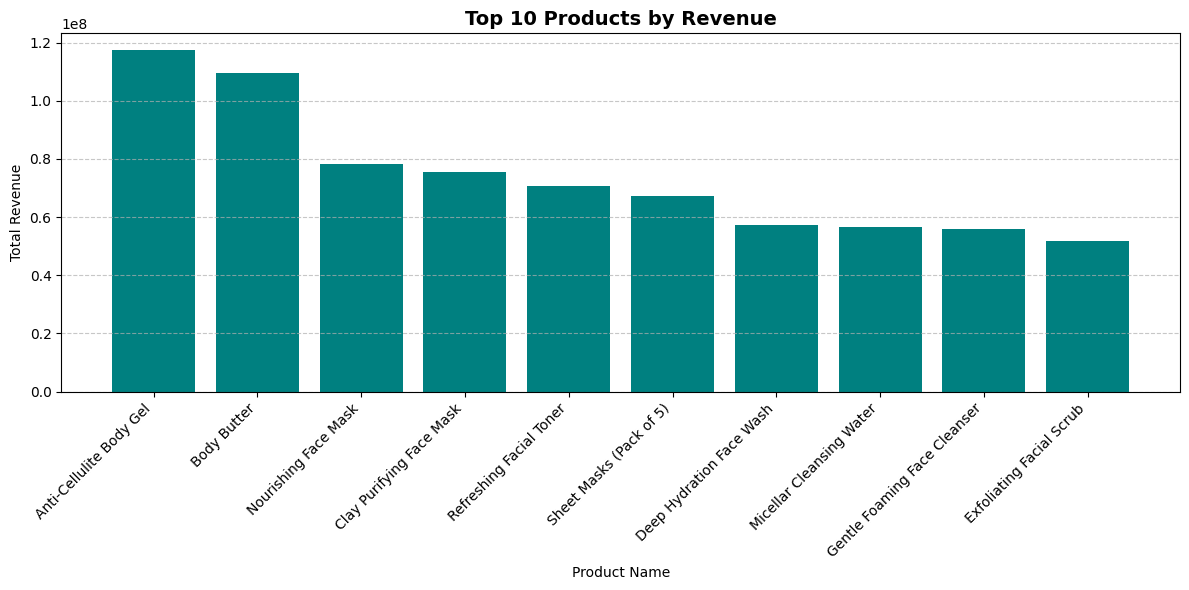

In [ ]:
# Group and rank by revenue
top10 = (
    df.groupby('product_name', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
plt.bar(top10['product_name'], top10['revenue'], color='teal')
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Read your dataset (replace with your actual file)
# Example: df = pd.read_csv("sales_data.csv")
# Ensure 'product_name' and 'revenue' columns exist
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Group by product and sum the revenue
top_products = (
    df.groupby('product_name', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
      .head(10)
)

# Format revenue for readability
top_products['revenue'] = top_products['revenue'].map('${:,.2f}'.format)

# Rename columns for table clarity
top_products = top_products.rename(columns={'product_name': 'Product Name', 'revenue': 'Total Revenue'})

# Display result as table
print("📊 Top 10 Products by Revenue")
print(top_products.to_string(index=False))


📊 Top 10 Products by Revenue
                Product Name   Total Revenue
     Anti-Cellulite Body Gel $117,291,821.40
                 Body Butter $109,473,966.60
        Nourishing Face Mask  $78,281,379.60
    Clay Purifying Face Mask  $75,390,396.60
     Refreshing Facial Toner  $70,804,380.60
     Sheet Masks (Pack of 5)  $67,331,623.20
    Deep Hydration Face Wash  $57,401,097.60
    Micellar Cleansing Water  $56,701,537.20
Gentle Foaming Face Cleanser  $55,952,289.60
    Exfoliating Facial Scrub  $51,764,816.40


*3.Orders by Channel (Pie chart).*

Orders by Channel:
channel
Wholesale      5766
Distributor    3328
Export         1590
Name: order_number, dtype: int64


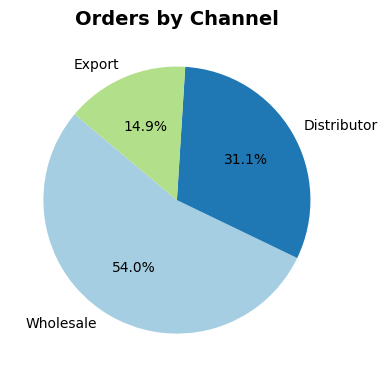

In [ ]:
# Group the data by 'channel' and count unique order numbers
orders_by_channel = (
    df.groupby('channel')['order_number']
      .nunique()
      .sort_values(ascending=False)
)

# Display the summarized data
print("Orders by Channel:")
print(orders_by_channel)

# Plot the Pie Chart
plt.figure(figsize=(4,4))
plt.pie(
    orders_by_channel,
    labels=orders_by_channel.index,
    autopct='%1.1f%%',     # show percentages
    startangle=140,        # rotate start angle
    colors=plt.cm.Paired.colors
)

plt.title('Orders by Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

*4. Product Sales Breakdown (Bar chart by product_name)*

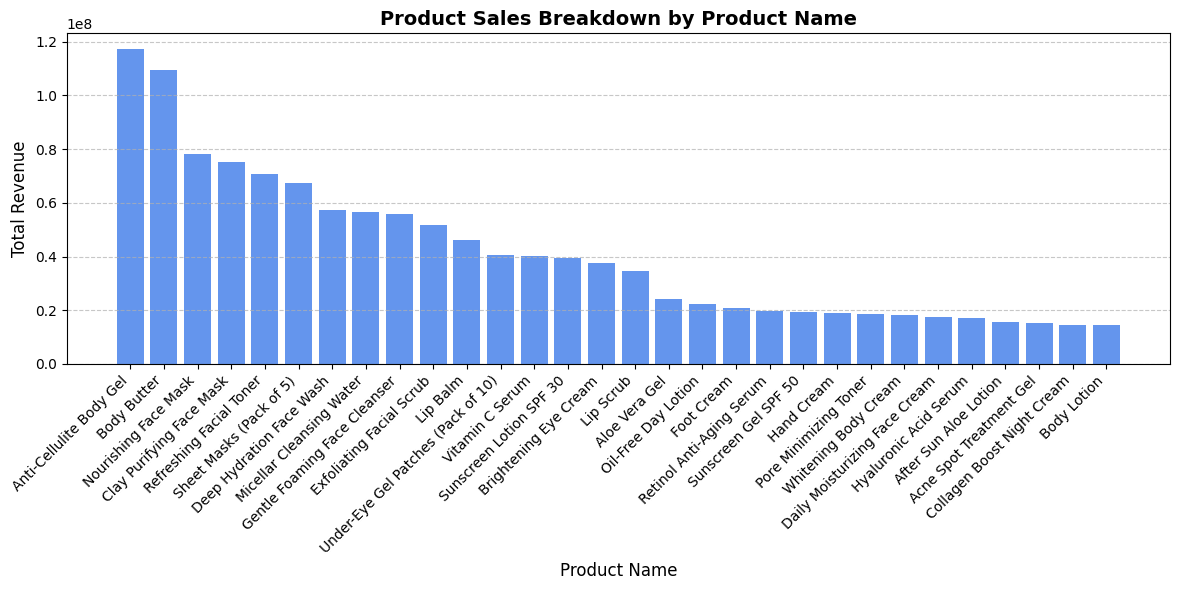

In [ ]:
# Group total revenue by product name
product_sales = (
    df.groupby('product_name', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

# Plot
plt.figure(figsize=(12,6))
plt.bar(product_sales['product_name'], product_sales['revenue'], color='cornflowerblue')

plt.title('Product Sales Breakdown by Product Name', fontsize=14, fontweight='bold')
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Ensure revenue is numeric
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Group total revenue by product name
product_sales = (
    df.groupby('product_name', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

# Format the revenue as currency for readability
product_sales['revenue'] = product_sales['revenue'].map('${:,.2f}'.format)

# Rename columns for better display
product_sales = product_sales.rename(columns={
    'product_name': 'Product Name',
    'revenue': 'Total Revenue'
})

# Display the result as a table
print("📊 Product Sales Breakdown Table")
print(product_sales.to_string(index=False))


📊 Product Sales Breakdown Table
                      Product Name   Total Revenue
           Anti-Cellulite Body Gel $117,291,821.40
                       Body Butter $109,473,966.60
              Nourishing Face Mask  $78,281,379.60
          Clay Purifying Face Mask  $75,390,396.60
           Refreshing Facial Toner  $70,804,380.60
           Sheet Masks (Pack of 5)  $67,331,623.20
          Deep Hydration Face Wash  $57,401,097.60
          Micellar Cleansing Water  $56,701,537.20
      Gentle Foaming Face Cleanser  $55,952,289.60
          Exfoliating Facial Scrub  $51,764,816.40
                          Lip Balm  $46,228,954.80
Under-Eye Gel Patches (Pack of 10)  $40,594,442.40
                   Vitamin C Serum  $40,149,147.00
           Sunscreen Lotion SPF 30  $39,645,159.60
             Brightening Eye Cream  $37,446,541.20
                         Lip Scrub  $34,446,174.00
                     Aloe Vera Gel  $24,173,184.60
               Oil-Free Day Lotion  $22,324,426.80

*5. Geographical Customer Map (Scatter by state or county)*

*6. Monthly Profit Trend (self) (Line chart)*

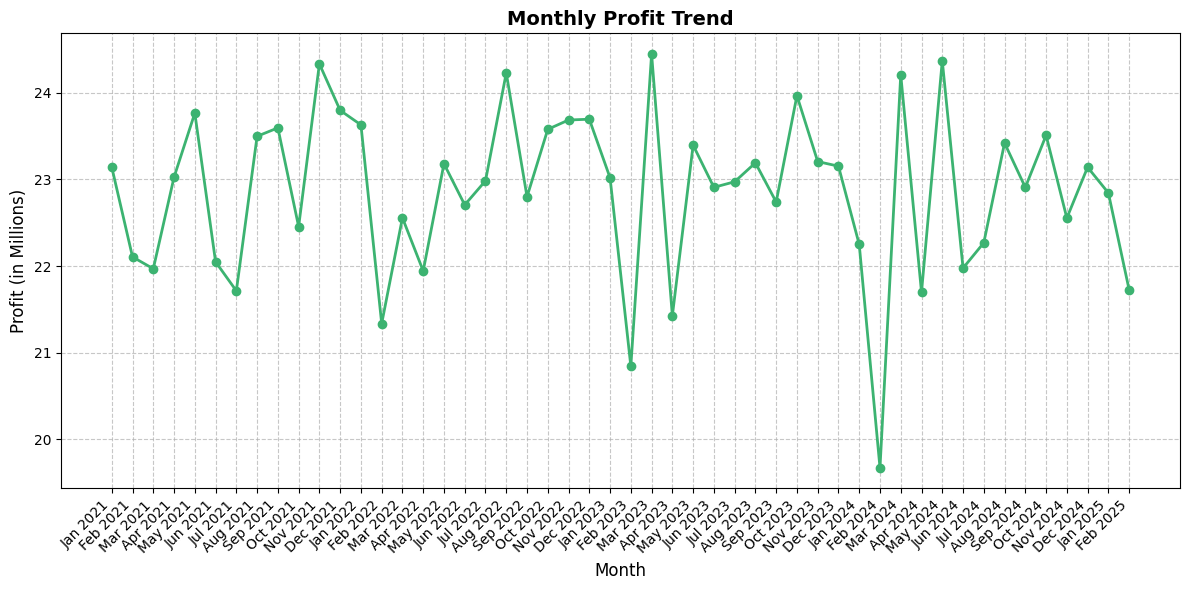

In [ ]:
# Calculate monthly profit
df['profit'] = df['revenue'] - df['total_unit_cost']

# Extract month-year from order_date
df['order_month'] = df['order_date'].dt.to_period('M')

# Group by month and sum profit
monthly_profit = df.groupby('order_month')['profit'].sum().reset_index()

# Convert period to string for labeling
monthly_profit['month_name'] = monthly_profit['order_month'].dt.strftime('%b %Y')

# Plot monthly profit trend
plt.figure(figsize=(12,6))
plt.plot(monthly_profit['month_name'], monthly_profit['profit']/1e6, color='mediumseagreen', marker='o', linewidth=2)

plt.title('Monthly Profit Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Profit (in Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Executive Viewer**



*1.Revenue & Profit Trend Over Time (Line chart by order_month).*











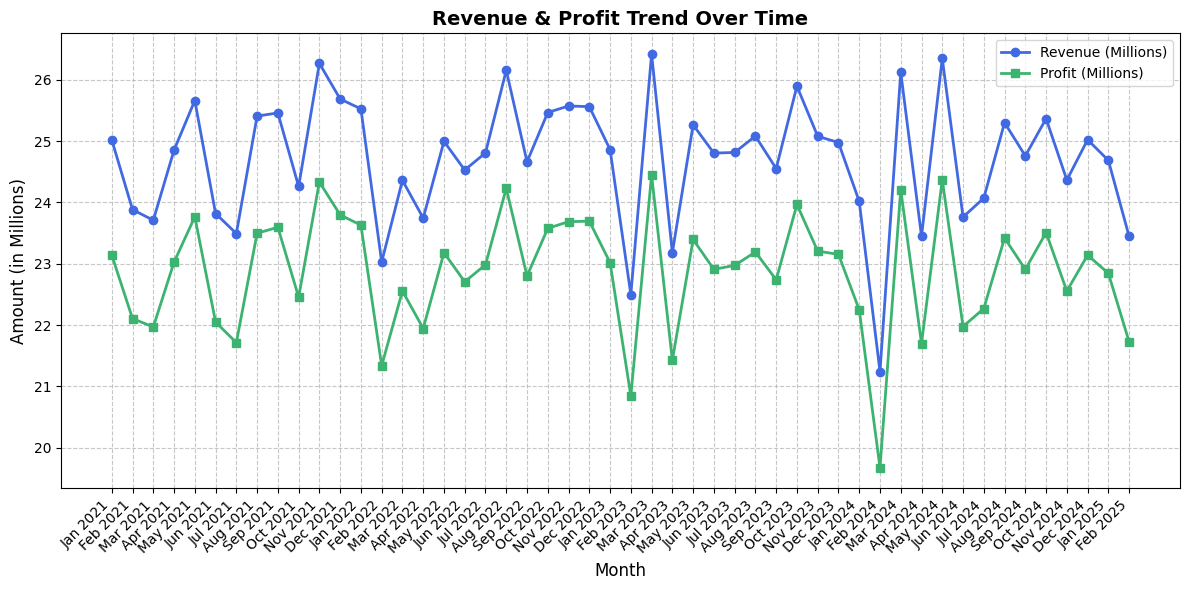

In [ ]:
# Calculate monthly period
df['order_month'] = df['order_date'].dt.to_period('M')

# Calculate profit for each record
df['profit'] = df['revenue'] - df['total_unit_cost']

# Group by month to get total revenue and profit
monthly_perf = (
    df.groupby('order_month')
      .agg(total_revenue=('revenue', 'sum'),
           total_profit=('profit', 'sum'))
      .reset_index()
)

# Convert to string for pretty labels
monthly_perf['month_name'] = monthly_perf['order_month'].dt.strftime('%b %Y')

# Plot dual-line chart
plt.figure(figsize=(12,6))
plt.plot(monthly_perf['month_name'], monthly_perf['total_revenue']/1e6,
         color='royalblue', marker='o', linewidth=2, label='Revenue (Millions)')
plt.plot(monthly_perf['month_name'], monthly_perf['total_profit']/1e6,
         color='mediumseagreen', marker='s', linewidth=2, label='Profit (Millions)')

# Styling
plt.title('Revenue & Profit Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount (in Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


\*2.Regional Revenue Distribution (Pie or choropleth-like scatter using latitude/longitude).*:



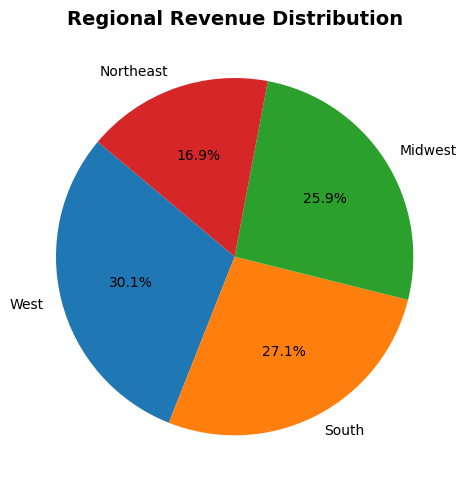

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure clean types
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Aggregate revenue by region
region_rev = (
    df.groupby('region', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

# Plot pie
plt.figure(figsize=(5,5))
plt.pie(region_rev['revenue'],
        labels=region_rev['region'],
        autopct='%1.1f%%',
        startangle=140)
plt.title('Regional Revenue Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:

# Ensure revenue column is numeric
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Group data by region and calculate total revenue
regional_revenue = (
    df.groupby('region', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

# Calculate each region's revenue share (% of total revenue)
total_revenue = regional_revenue['revenue'].sum()
regional_revenue['Revenue_Share_%'] = (regional_revenue['revenue'] / total_revenue) * 100

# Format currency and percentage
regional_revenue['revenue'] = regional_revenue['revenue'].map('${:,.2f}'.format)
regional_revenue['Revenue_Share_%'] = regional_revenue['Revenue_Share_%'].map('{:.2f}%'.format)

# Rename columns for better readability
regional_revenue = regional_revenue.rename(columns={
    'region': 'Region',
    'revenue': 'Total Revenue'
})

# Display table
print("📍 Regional Revenue Distribution Table")
print(regional_revenue.to_string(index=False))


📍 Regional Revenue Distribution Table
   Region   Total Revenue Revenue_Share_%
     West $372,142,307.60          30.11%
    South $335,135,011.70          27.12%
  Midwest $320,322,363.60          25.92%
Northeast $208,369,216.10          16.86%


*3.Top 10 Performing States (Bar chart).*

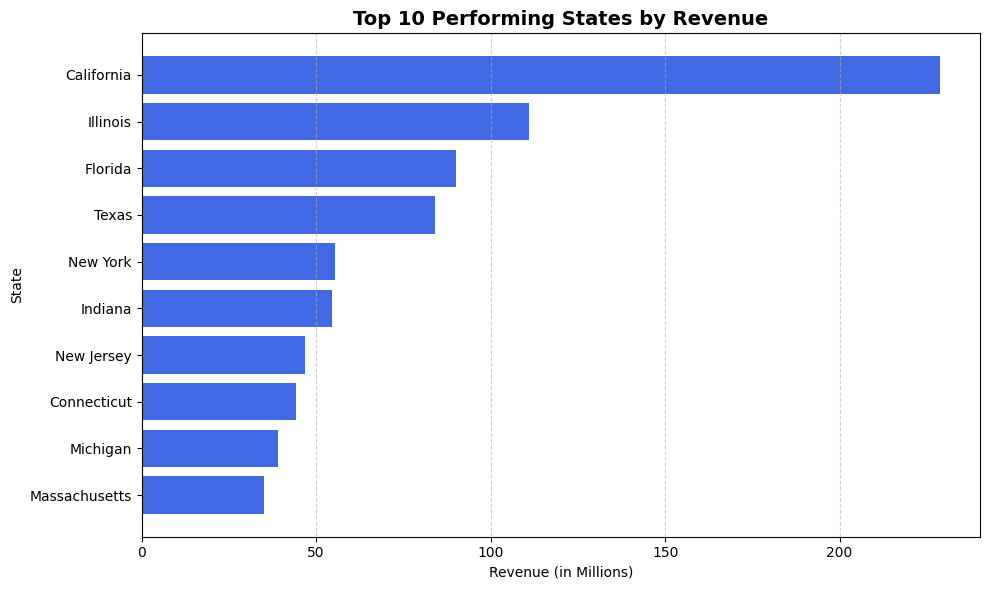

In [ ]:
# ensure revenue is numeric
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# aggregate total revenue by state and sort
top_states = (
    df.groupby('state', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
      .head(10)
)

# plot
plt.figure(figsize=(10,6))
plt.barh(top_states['state'], top_states['revenue']/1e6, color='royalblue')
plt.gca().invert_yaxis()  # largest at the top
plt.title('Top 10 Performing States by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (in Millions)')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


*4.Year-over-Year Growth % (Line or bar).*



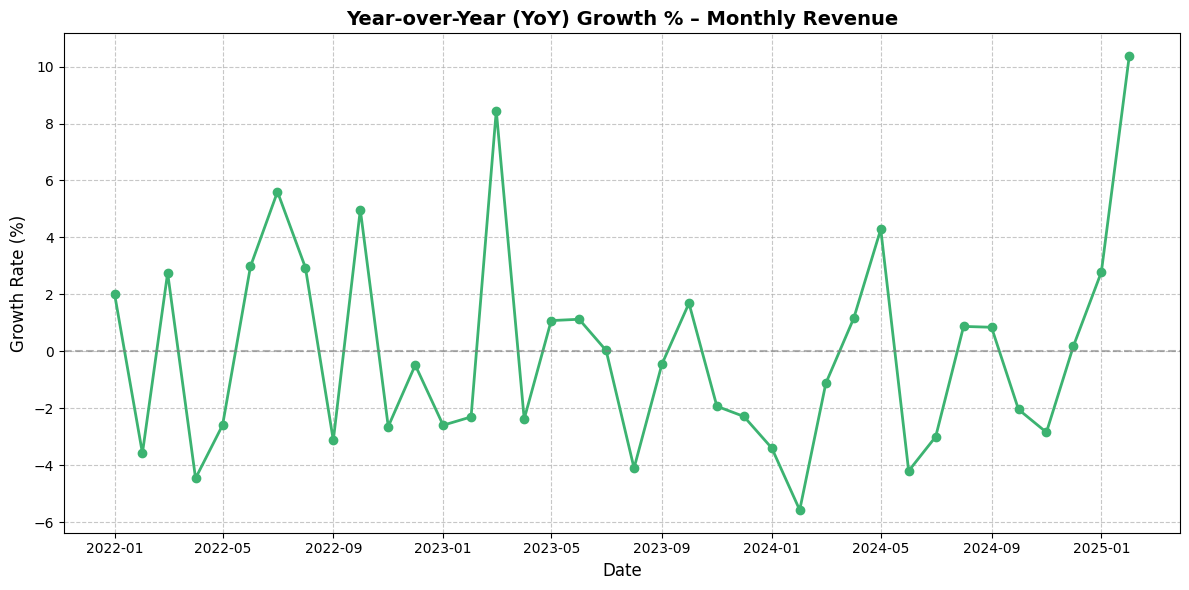

In [ ]:
# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Extract year and month for grouping
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

# Group total revenue by year and month
monthly_revenue = (
    df.groupby(['year', 'month'])['revenue']
      .sum()
      .reset_index()
)

# Create a date column for plotting
monthly_revenue['date'] = pd.to_datetime(
    monthly_revenue[['year', 'month']].assign(day=1)
)

# Sort chronologically
monthly_revenue = monthly_revenue.sort_values('date')

# Calculate Year-over-Year Growth %
monthly_revenue['YoY_Growth_%'] = monthly_revenue['revenue'].pct_change(periods=12) * 100

# Drop rows with NaN (first 12 months will have no YoY comparison)
monthly_yoy = monthly_revenue.dropna(subset=['YoY_Growth_%'])

# Plot YoY growth trend
plt.figure(figsize=(12,6))
plt.plot(monthly_yoy['date'], monthly_yoy['YoY_Growth_%'],
         color='mediumseagreen', marker='o', linewidth=2)

plt.title('Year-over-Year (YoY) Growth % – Monthly Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


*5.Channel Contribution (Stacked bar of revenue by channel).*

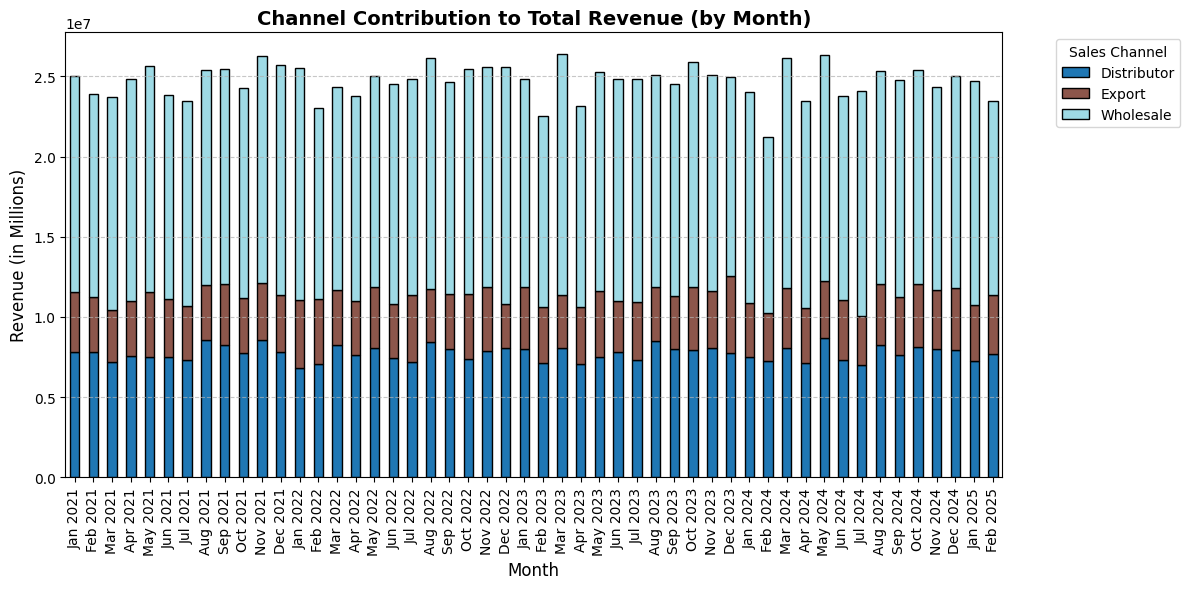

In [ ]:
# Ensure correct types
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Extract month/year for grouping
df['order_month'] = df['order_date'].dt.to_period('M')

# Group total revenue by month and channel
channel_contrib = (
    df.groupby(['order_month', 'channel'])['revenue']
      .sum()
      .reset_index()
)

# Pivot for stacked bar chart (months as rows, channels as columns)
channel_pivot = channel_contrib.pivot(index='order_month', columns='channel', values='revenue').fillna(0)

# Convert period to string for better labeling
channel_pivot.index = channel_pivot.index.to_timestamp()
channel_pivot.index = channel_pivot.index.strftime('%b %Y')

# Plot stacked bar
channel_pivot.plot(kind='bar', stacked=True, figsize=(12,6),
                   colormap='tab20', edgecolor='black')

plt.title('Channel Contribution to Total Revenue (by Month)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (in Millions)', fontsize=12)
plt.legend(title='Sales Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Sales Manager**



*1.Sales by Region(Heatmap or bar chart).*



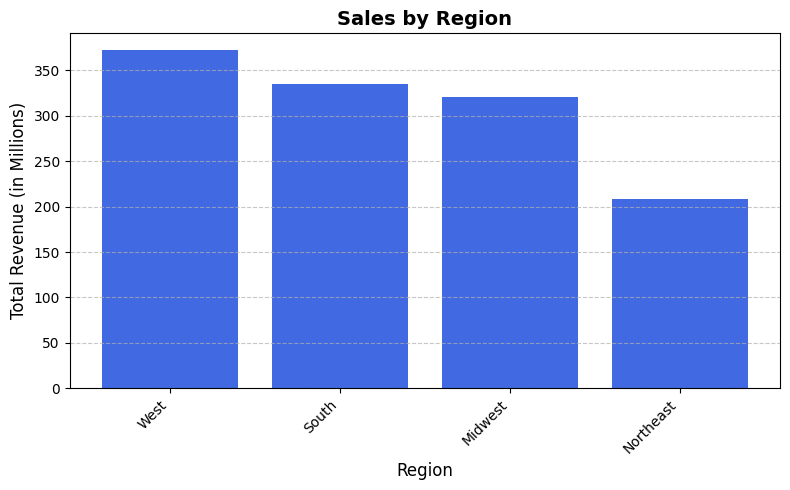

In [ ]:
# Group total revenue by region or state
region_sales = (
    df.groupby('region', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(region_sales['region'], region_sales['revenue']/1e6, color='royalblue')

plt.title('Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Revenue (in Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


*2.Sales by State (Heatmap or bar chart)*


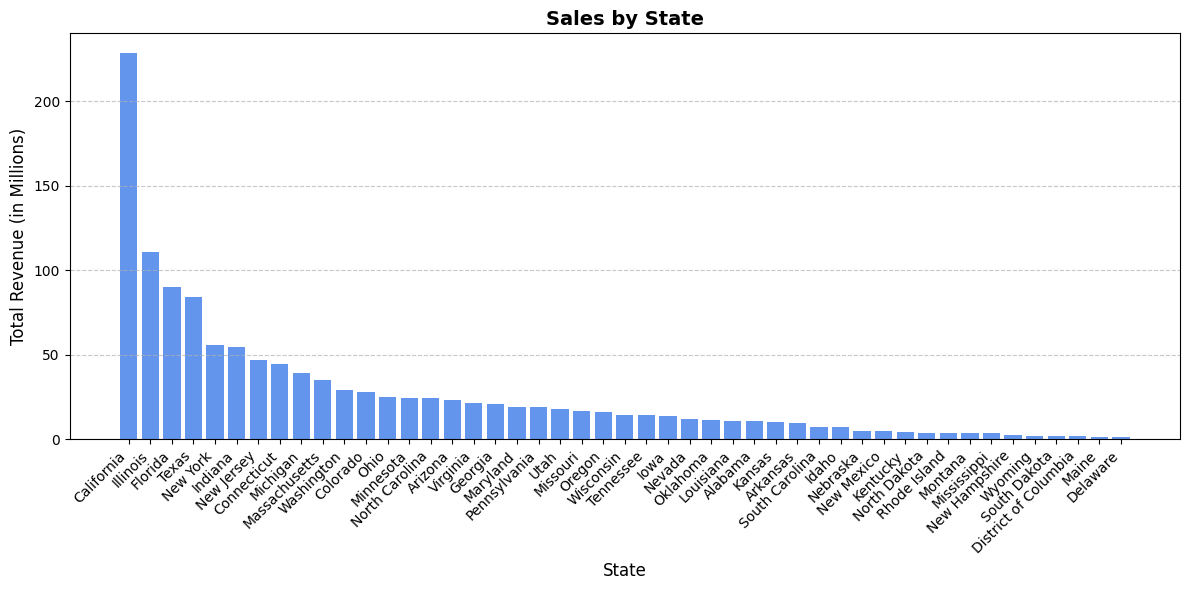

In [ ]:


# Group total revenue by state
state_sales = (
    df.groupby('state', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(state_sales['state'], state_sales['revenue']/1e6, color='cornflowerblue')

plt.title('Sales by State', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Revenue (in Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Ensure revenue is numeric
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Group total revenue by state
sales_by_state = (
    df.groupby('state', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

# Format revenue as currency for readability
sales_by_state['revenue'] = sales_by_state['revenue'].map('${:,.2f}'.format)

# Rename columns for better presentation
sales_by_state = sales_by_state.rename(columns={
    'state': 'State',
    'revenue': 'Total Revenue'
})

# Display table
print("📍 Sales by State Table")
print(sales_by_state.to_string(index=False))


📍 Sales by State Table
               State   Total Revenue
          California $228,785,436.00
            Illinois $111,050,965.70
             Florida  $90,204,679.50
               Texas  $84,011,903.00
            New York  $55,534,960.00
             Indiana  $54,601,690.20
          New Jersey  $46,830,956.50
         Connecticut  $44,251,228.70
            Michigan  $39,025,315.80
       Massachusetts  $35,011,942.10
          Washington  $28,915,853.30
            Colorado  $27,683,776.90
                Ohio  $25,214,518.70
           Minnesota  $24,520,928.00
      North Carolina  $24,123,068.60
             Arizona  $23,388,246.10
            Virginia  $21,385,026.50
             Georgia  $20,726,912.30
            Maryland  $19,361,780.60
        Pennsylvania  $19,228,068.70
                Utah  $17,914,393.00
            Missouri  $16,878,358.60
              Oregon  $16,100,106.70
           Wisconsin  $14,586,503.00
           Tennessee  $14,123,365.50
               

*3.Monthly Sales Performance Trend (Line chart).*

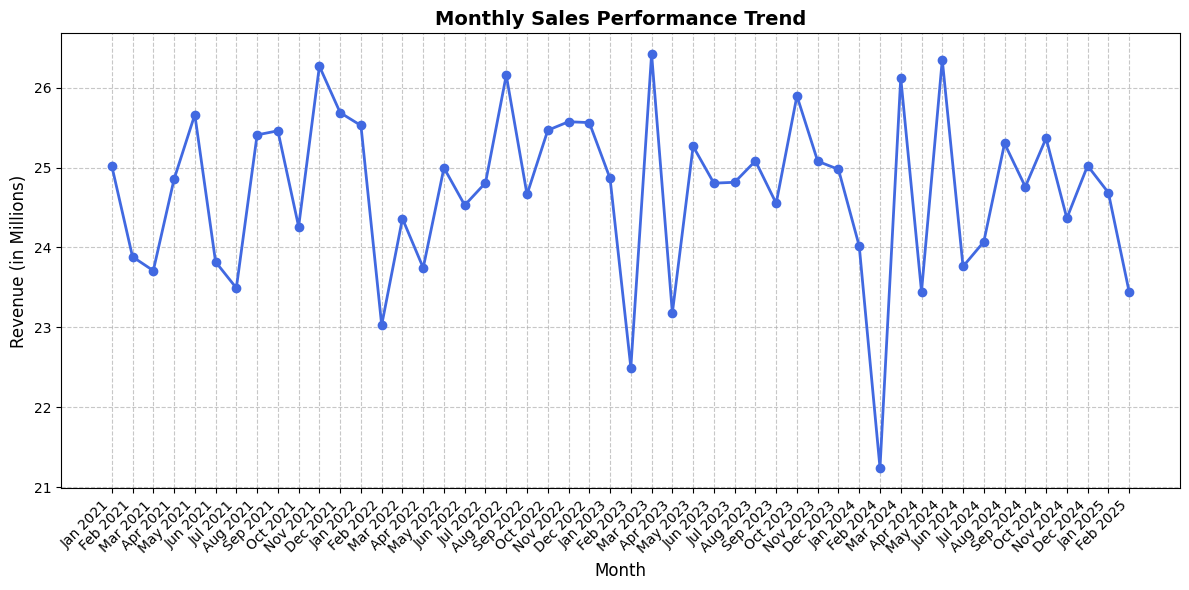

In [ ]:


# Extract Year-Month for grouping
df['order_month'] = df['order_date'].dt.to_period('M')

# Group by month to calculate total revenue
monthly_sales = (
    df.groupby('order_month')['revenue']
      .sum()
      .reset_index()
)

# Convert for prettier labels
monthly_sales['month_name'] = monthly_sales['order_month'].dt.strftime('%b %Y')

# Plot line chart
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['month_name'], monthly_sales['revenue']/1e6,
         color='royalblue', marker='o', linewidth=2)

plt.title('Monthly Sales Performance Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (in Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



*4.Orders vs. Budgets (Scatter plot).*

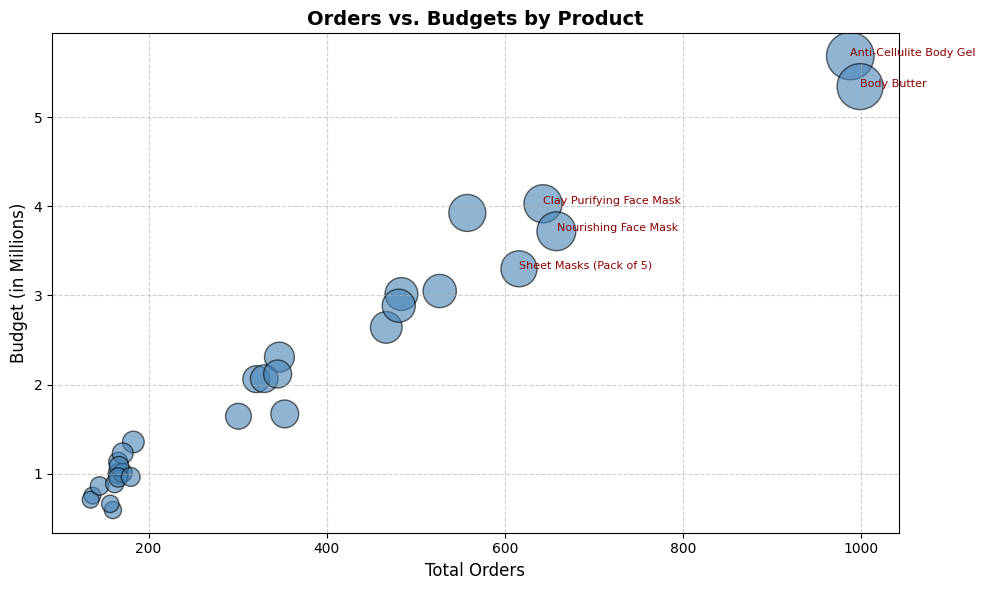

In [ ]:

# Ensure numeric data
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budgets'] = pd.to_numeric(df['budgets'], errors='coerce')

# Group by product_name (or region if you want a regional comparison)
orders_vs_budgets = (
    df.groupby('product_name', as_index=False)
      .agg(total_orders=('order_number', 'nunique'),
           total_revenue=('revenue', 'sum'),
           total_budget=('budgets', 'mean'))   # budget per product (2017 Budgets table)
)

# Drop products with missing budgets
orders_vs_budgets = orders_vs_budgets.dropna(subset=['total_budget'])

# Scatter plot — Orders (X) vs Budget (Y)
plt.figure(figsize=(10,6))
plt.scatter(orders_vs_budgets['total_orders'],
            orders_vs_budgets['total_budget']/1e6,
            s=orders_vs_budgets['total_revenue']/1e6*10,  # bubble size = revenue
            alpha=0.6, color='steelblue', edgecolors='black')

plt.title('Orders vs. Budgets by Product', fontsize=14, fontweight='bold')
plt.xlabel('Total Orders', fontsize=12)
plt.ylabel('Budget (in Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate top 5 outliers
top5 = orders_vs_budgets.nlargest(5, 'total_orders')
for _, row in top5.iterrows():
    plt.text(row['total_orders']+0.2, row['total_budget']/1e6,
             row['product_name'], fontsize=8, color='darkred')

plt.tight_layout()
plt.show()


**Sales Analyst**

*2.Correlation Heatmap (between unit price, order quantity, profit margin).*


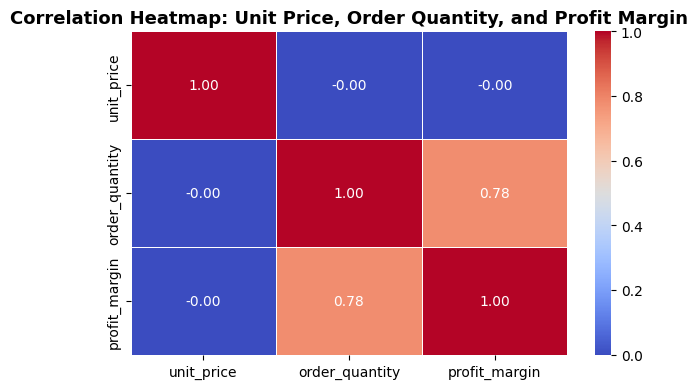

In [ ]:
  # Ensure numeric columns
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')
df['order_quantity'] = pd.to_numeric(df['order_quantity'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['total_unit_cost'] = pd.to_numeric(df['total_unit_cost'], errors='coerce')

# Calculate profit margin
df['profit'] = df['revenue'] - df['total_unit_cost']
df['profit_margin'] = (df['profit'] / df['revenue']) * 100

# Select relevant numeric columns
corr_data = df[['unit_price', 'order_quantity', 'profit_margin']].copy()

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')

plt.title('Correlation Heatmap: Unit Price, Order Quantity, and Profit Margin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


*3.Distribution of Profit Margins (Histogram).*



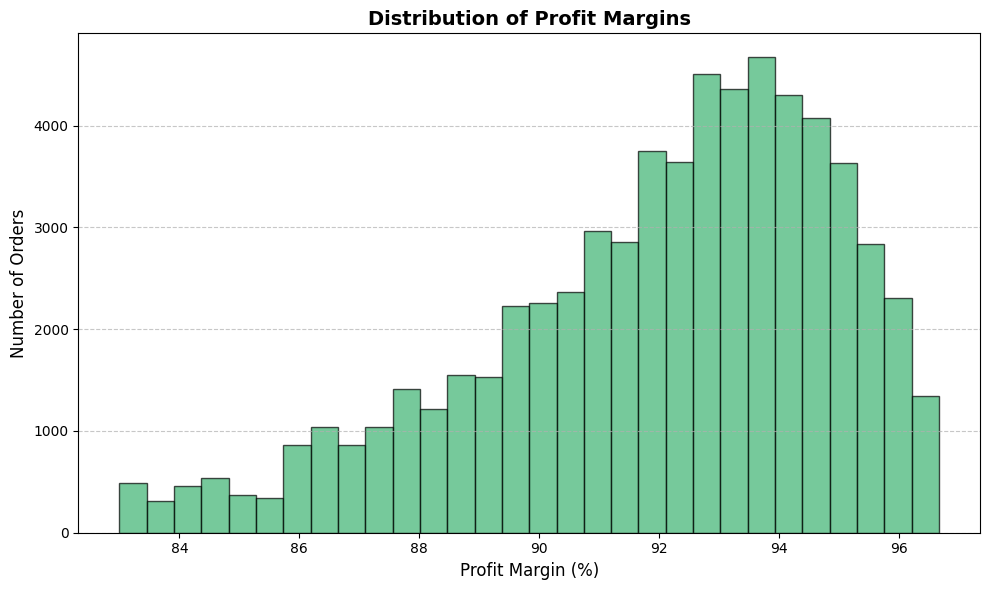

In [ ]:

# Ensure numeric columns
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['total_unit_cost'] = pd.to_numeric(df['total_unit_cost'], errors='coerce')

# Compute Profit and Profit Margin
df['profit'] = df['revenue'] - df['total_unit_cost']
df['profit_margin'] = (df['profit'] / df['revenue']) * 100   # percentage

# Drop invalid or infinite margins
df = df.replace([float('inf'), -float('inf')], pd.NA).dropna(subset=['profit_margin'])

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(df['profit_margin'], bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)

plt.title('Distribution of Profit Margins', fontsize=14, fontweight='bold')
plt.xlabel('Profit Margin (%)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


*4.Seasonality of Orders (Line plot by order_month).*


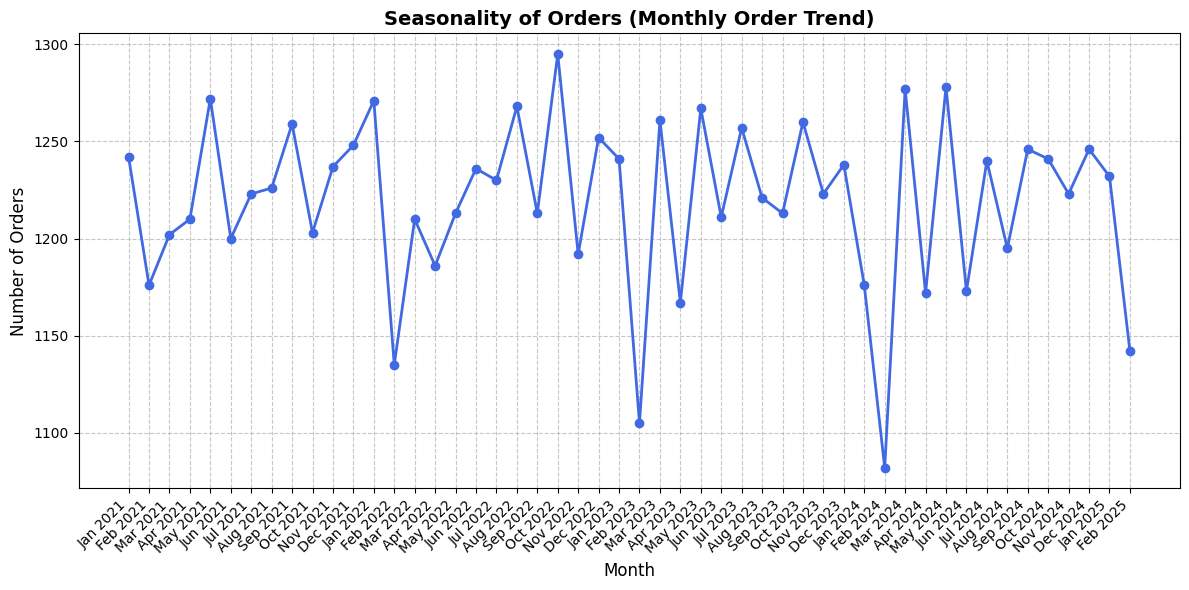

In [ ]:

# Extract month and year
df['order_month'] = df['order_date'].dt.to_period('M')

# Group by month to count unique orders
monthly_orders = (
    df.groupby('order_month')['order_number']
      .nunique()
      .reset_index(name='total_orders')
)

# Convert month for better visualization
monthly_orders['month_name'] = monthly_orders['order_month'].dt.strftime('%b %Y')

# Plot line chart
plt.figure(figsize=(12,6))
plt.plot(monthly_orders['month_name'], monthly_orders['total_orders'],
         color='royalblue', marker='o', linewidth=2)

plt.title('Seasonality of Orders (Monthly Order Trend)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


*5.Channel Efficiency (Bar chart: revenue per order or profit per order by channel).*


       channel  total_revenue  total_profit  total_orders  revenue_per_order  \
0  Distributor    387139788.6  3.582734e+08          3328      116328.061478   
1       Export    180631866.0  1.673449e+08          1590      113604.947170   
2    Wholesale    668197244.4  6.185483e+08          5766      115885.751717   

   profit_per_order  
0     107654.254484  
1     105248.356242  
2     107275.120944  


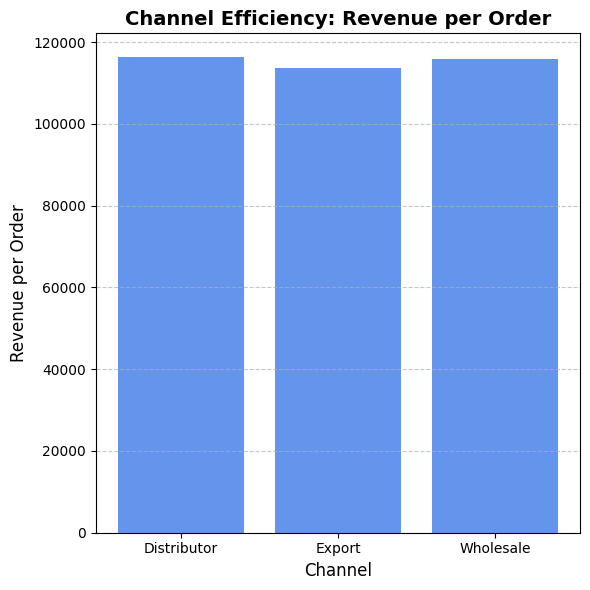

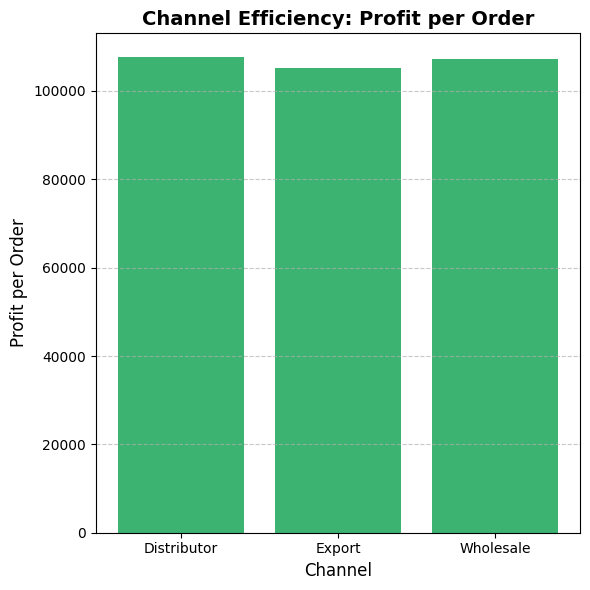

In [ ]:


# Ensure correct data types
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['total_unit_cost'] = pd.to_numeric(df['total_unit_cost'], errors='coerce')

# Calculate profit for each record
df['profit'] = df['revenue'] - df['total_unit_cost']

# Group by channel to calculate total revenue, profit, and order count
channel_efficiency = (
    df.groupby('channel', as_index=False)
      .agg(total_revenue=('revenue', 'sum'),
           total_profit=('profit', 'sum'),
           total_orders=('order_number', 'nunique'))
)

# Calculate efficiency metrics
channel_efficiency['revenue_per_order'] = channel_efficiency['total_revenue'] / channel_efficiency['total_orders']
channel_efficiency['profit_per_order'] = channel_efficiency['total_profit'] / channel_efficiency['total_orders']

# Display data
print(channel_efficiency)

# Plot – Revenue per Order
plt.figure(figsize=(6,6))
plt.bar(channel_efficiency['channel'], channel_efficiency['revenue_per_order'], color='cornflowerblue')
plt.title('Channel Efficiency: Revenue per Order', fontsize=14, fontweight='bold')
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Revenue per Order', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot – Profit per Order
plt.figure(figsize=(6,6))
plt.bar(channel_efficiency['channel'], channel_efficiency['profit_per_order'], color='mediumseagreen')
plt.title('Channel Efficiency: Profit per Order', fontsize=14, fontweight='bold')
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Profit per Order', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



*6.Cost Structure Analysis (Stacked bar: total_unit_cost vs. revenue vs. profit).*

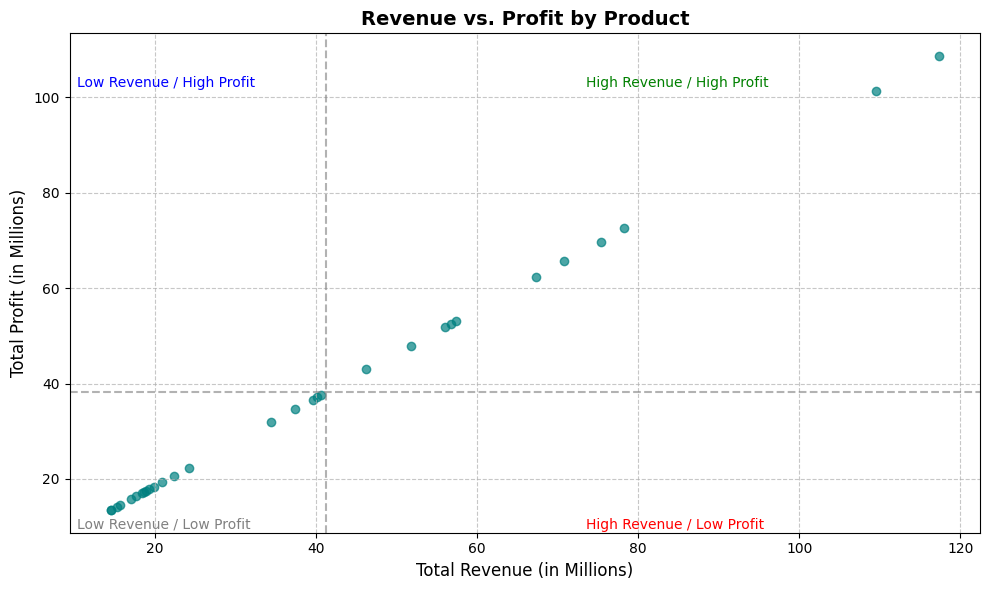

In [ ]:
# Ensure columns are numeric and clean
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['total_unit_cost'] = pd.to_numeric(df['total_unit_cost'], errors='coerce')

# Calculate Profit per row
df['profit'] = df['revenue'] - df['total_unit_cost']

# Group by product to get total revenue and total profit
product_profitability = (
    df.groupby('product_name', as_index=False)
      .agg(total_revenue=('revenue', 'sum'),
           total_profit=('profit', 'sum'))
)

# Plot Scatter Chart
plt.figure(figsize=(10,6))
plt.scatter(product_profitability['total_revenue']/1e6,
            product_profitability['total_profit']/1e6,
            alpha=0.7, color='teal')

# Add chart details
plt.title('Revenue vs. Profit by Product', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (in Millions)', fontsize=12)
plt.ylabel('Total Profit (in Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight quadrant interpretation
plt.axvline(product_profitability['total_revenue'].mean()/1e6, color='gray', linestyle='--', alpha=0.6)
plt.axhline(product_profitability['total_profit'].mean()/1e6, color='gray', linestyle='--', alpha=0.6)
plt.text(plt.xlim()[1]*0.6, plt.ylim()[1]*0.9, 'High Revenue / High Profit', color='green')
plt.text(plt.xlim()[0]*1.1, plt.ylim()[1]*0.9, 'Low Revenue / High Profit', color='blue')
plt.text(plt.xlim()[1]*0.6, plt.ylim()[0]*1.1, 'High Revenue / Low Profit', color='red')
plt.text(plt.xlim()[0]*1.1, plt.ylim()[0]*1.1, 'Low Revenue / Low Profit', color='gray')

plt.tight_layout()
plt.show()


**Sales Executive**



*2.Top 10 Customers by Revenue (Bar chart).*

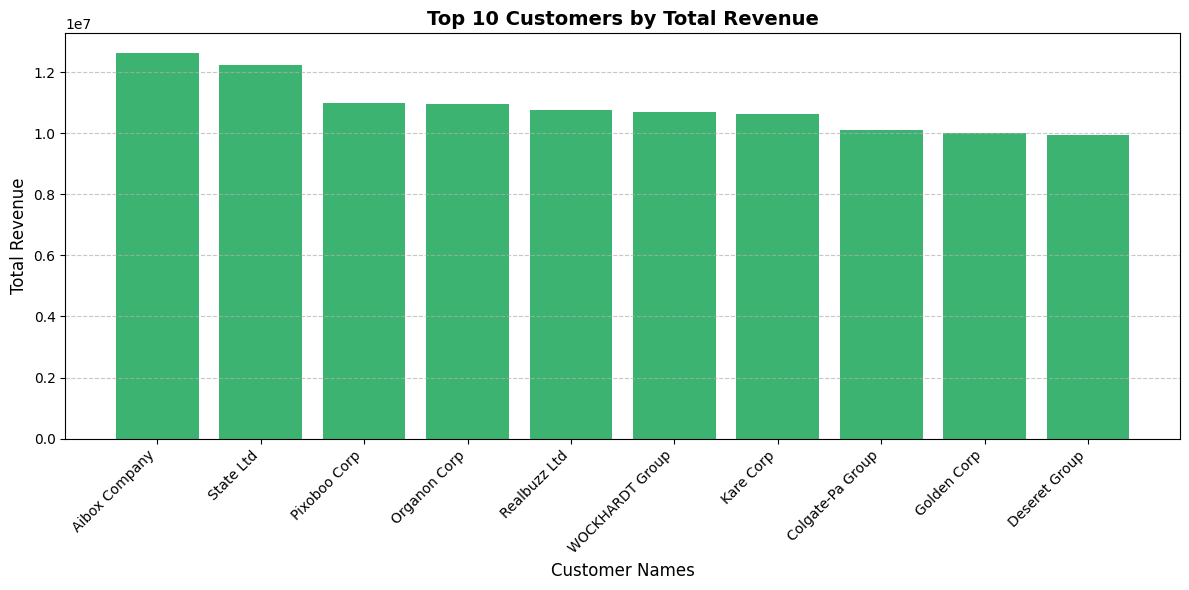

In [ ]:
# Group and rank by total revenue per customer
top10_customers = (
    df.groupby('customer_names', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
      .head(10)
)

# Plot
plt.figure(figsize=(12,6))
plt.bar(top10_customers['customer_names'], top10_customers['revenue'], color='mediumseagreen')

plt.title('Top 10 Customers by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Customer Names', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


*5.Geographical Customer Map (Scatter by state or county).*

In [ ]:
import pandas as pd

# Ensure data types
df['customer_names'] = df['customer_names'].astype(str)
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# -------- OPTION 1: By STATE --------
geo_state = (
    df.groupby(['state'], as_index=False)
      .agg(
          Total_Revenue=('revenue', 'sum')
      )
      .sort_values('Total_Revenue', ascending=False)
)

# Format revenue for readability
geo_state['Total_Revenue'] = geo_state['Total_Revenue'].map('${:,.2f}'.format)

print("📍 Geographical Customer Data Table (By State)")
print(geo_state.to_string(index=False))


📍 Geographical Customer Data Table (By State)
               state   Total_Revenue
          California $228,785,436.00
            Illinois $111,050,965.70
             Florida  $90,204,679.50
               Texas  $84,011,903.00
            New York  $55,534,960.00
             Indiana  $54,601,690.20
          New Jersey  $46,830,956.50
         Connecticut  $44,251,228.70
            Michigan  $39,025,315.80
       Massachusetts  $35,011,942.10
          Washington  $28,915,853.30
            Colorado  $27,683,776.90
                Ohio  $25,214,518.70
           Minnesota  $24,520,928.00
      North Carolina  $24,123,068.60
             Arizona  $23,388,246.10
            Virginia  $21,385,026.50
             Georgia  $20,726,912.30
            Maryland  $19,361,780.60
        Pennsylvania  $19,228,068.70
                Utah  $17,914,393.00
            Missouri  $16,878,358.60
              Oregon  $16,100,106.70
           Wisconsin  $14,586,503.00
           Tennessee  $14,123

A — Static scatter map

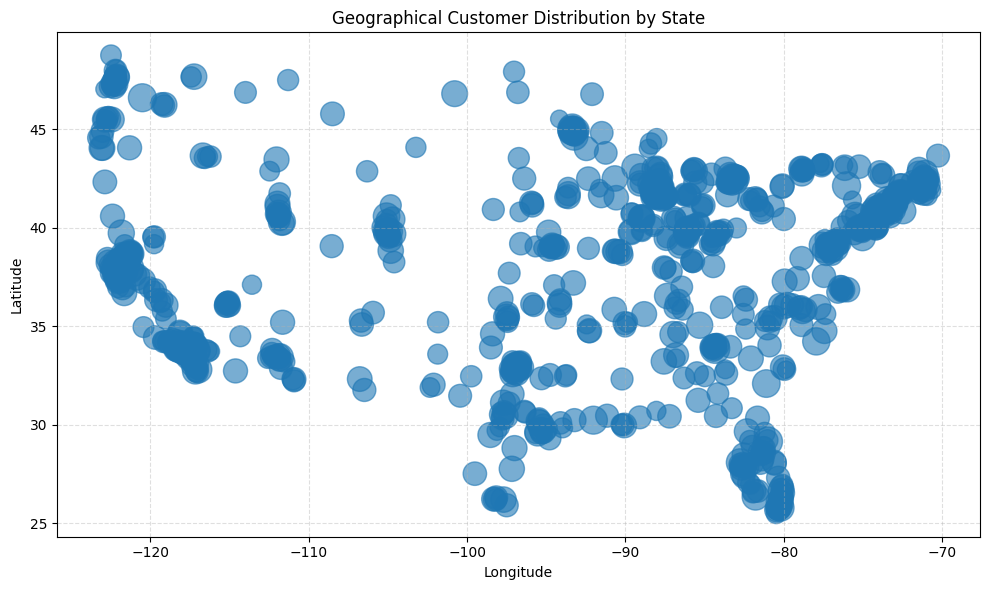

In [ ]:


# 1) Prepare customer counts per location (state or county)
# By STATE:
state_counts = (df.groupby(['state', 'latitude', 'longitude'])['customer_names']
                  .nunique()
                  .reset_index(name='customer_count'))

# 2) Plot as a scatter (bubble size ~ customers)
plt.figure(figsize=(10,6))
plt.scatter(state_counts['longitude'], state_counts['latitude'],
            s=state_counts['customer_count']*5, alpha=0.6)

plt.title('Geographical Customer Distribution by State')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


B — Interactive map (Plotly Express)

In [ ]:
import plotly.express as px

# Aggregate customers and (optional) revenue by STATE
state_agg = (df.groupby(['state', 'latitude', 'longitude'], as_index=False)
               .agg(customer_count=('customer_names', 'nunique'),
                    total_revenue=('revenue', 'sum')))

# Create scatter map (hover with state, customers, revenue)
fig = px.scatter_geo(
    state_agg,
    lat='latitude',
    lon='longitude',
    hover_name='state',
    hover_data={'customer_count': True, 'total_revenue': ':.2f', 'latitude': False, 'longitude': False},
    size='customer_count',
    projection='natural earth',
    title='Geographical Customer Map (by State)',
)

fig.update_layout(margin=dict(l=10, r=10, t=40, b=10))
fig.show()


Variant — County-level scatter

In [ ]:
# County aggregation
county_agg = (df.groupby(['state', 'county', 'latitude', 'longitude'], as_index=False)
                .agg(customer_count=('customer_names', 'nunique'),
                     total_revenue=('revenue', 'sum')))

# Plotly
fig = px.scatter_geo(
    county_agg,
    lat='latitude', lon='longitude',
    hover_name='county',
    hover_data={'state': True, 'customer_count': True, 'total_revenue': ':.2f'},
    size='customer_count',
    projection='natural earth',
    title='Geographical Customer Map (by County)'
)
fig.show()


In [ ]:
import pandas as pd

# Ensure columns are clean
df['customer_names'] = df['customer_names'].astype(str)
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Group data by State (you can change to ['region'] or ['state', 'county'] if needed)
geo_customer_data = (
    df.groupby(['state', 'region'], as_index=False)
      .agg(
          Unique_Customers=('customer_names', 'nunique'),
          Total_Revenue=('revenue', 'sum')
      )
      .sort_values('Total_Revenue', ascending=False)
)

# Format revenue for readability
geo_customer_data['Total_Revenue'] = geo_customer_data['Total_Revenue'].map('${:,.2f}'.format)

# Display the table
print("📍 Geographical Customer Data Table (by State & Region)")
print(geo_customer_data.to_string(index=False))


geo_customer_data.to_excel('geographical_customer_data.xlsx', index=False)
geo_customer_data.to_html('geographical_customer_data.html', index=False)


📍 Geographical Customer Data Table (by State & Region)
               state    region  Unique_Customers   Total_Revenue
          California      West               175 $228,785,436.00
            Illinois   Midwest               175 $111,050,965.70
             Florida     South               175  $90,204,679.50
               Texas     South               175  $84,011,903.00
            New York Northeast               175  $55,534,960.00
             Indiana   Midwest               175  $54,601,690.20
          New Jersey Northeast               175  $46,830,956.50
         Connecticut Northeast               175  $44,251,228.70
            Michigan   Midwest               175  $39,025,315.80
       Massachusetts Northeast               175  $35,011,942.10
          Washington      West               175  $28,915,853.30
            Colorado      West               173  $27,683,776.90
                Ohio   Midwest               175  $25,214,518.70
           Minnesota   Midwest     

**Monthly sales analysis over a period of time including 2025**

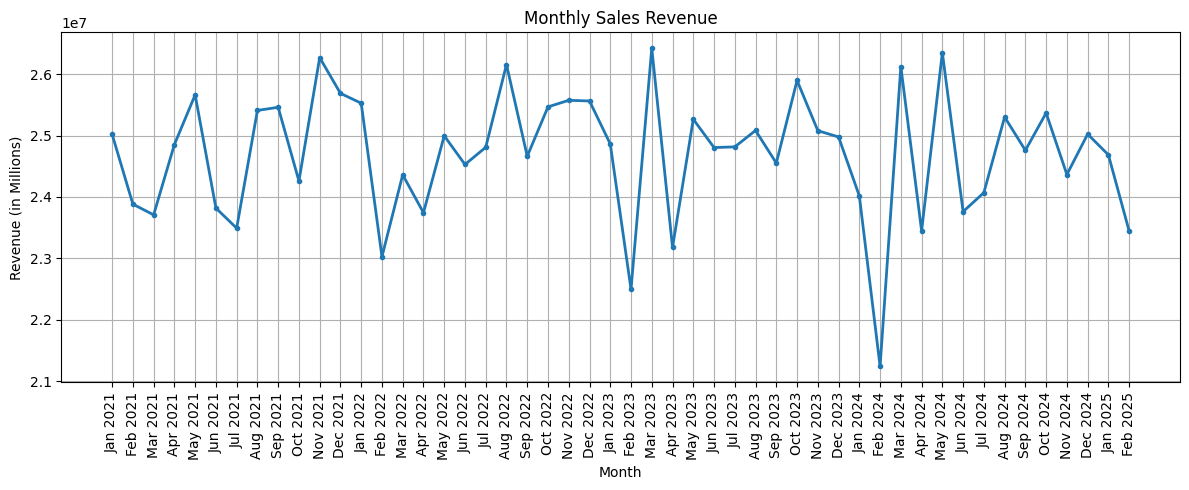

In [ ]:


# Create a monthly column from the date
df['order_month'] = pd.to_datetime(df['order_date']).dt.to_period('M')

# Aggregate total revenue by month
monthly_sales = df.groupby('order_month')['revenue'].sum().reset_index()

# Convert to string month names for prettier X-axis
monthly_sales['month_name'] = monthly_sales['order_month'].dt.strftime('%b %Y')

# Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['month_name'], monthly_sales['revenue'], marker='.', linewidth=2)

plt.title('Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (in Millions)')
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



**Monthly sales analysis over a period of time not including 2025**



/tmp/ipython-input-102910897.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



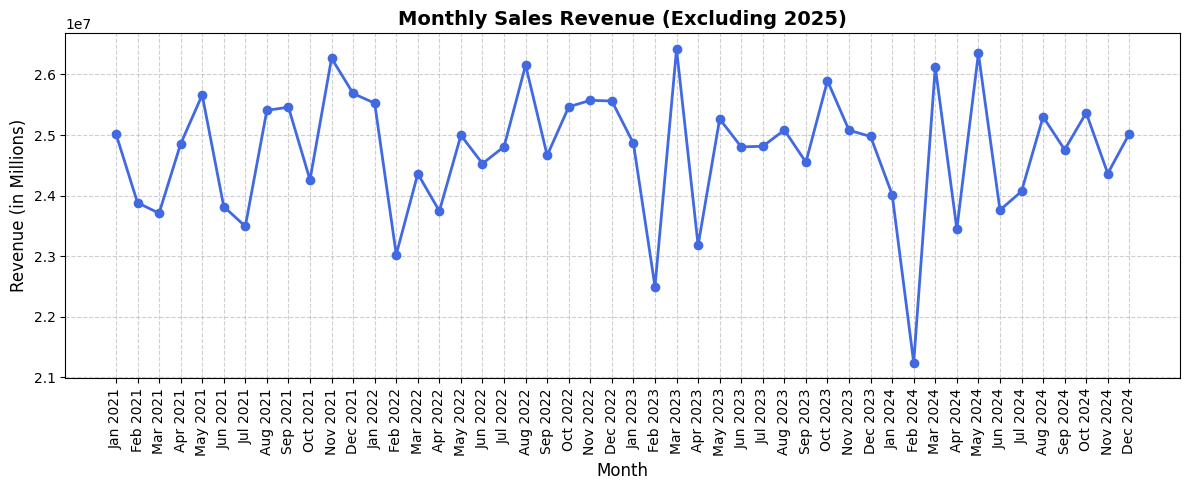

In [ ]:
#Monthly sales analysis over a period of time not including 2025

# Ensure order_date is in datetime format
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Filter data to exclude 2025
df_filtered = df[df['order_date'].dt.year != 2025]

# Create a monthly column from the date
df_filtered['order_month'] = df_filtered['order_date'].dt.to_period('M')

# Aggregate total revenue by month
monthly_sales = df_filtered.groupby('order_month')['revenue'].sum().reset_index()

# Convert to string month names for a readable X-axis
monthly_sales['month_name'] = monthly_sales['order_month'].dt.strftime('%b %Y')

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['month_name'], monthly_sales['revenue'], marker='o', linewidth=2, color='royalblue')

plt.title('Monthly Sales Revenue (Excluding 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (in Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**Products by total Revenue**

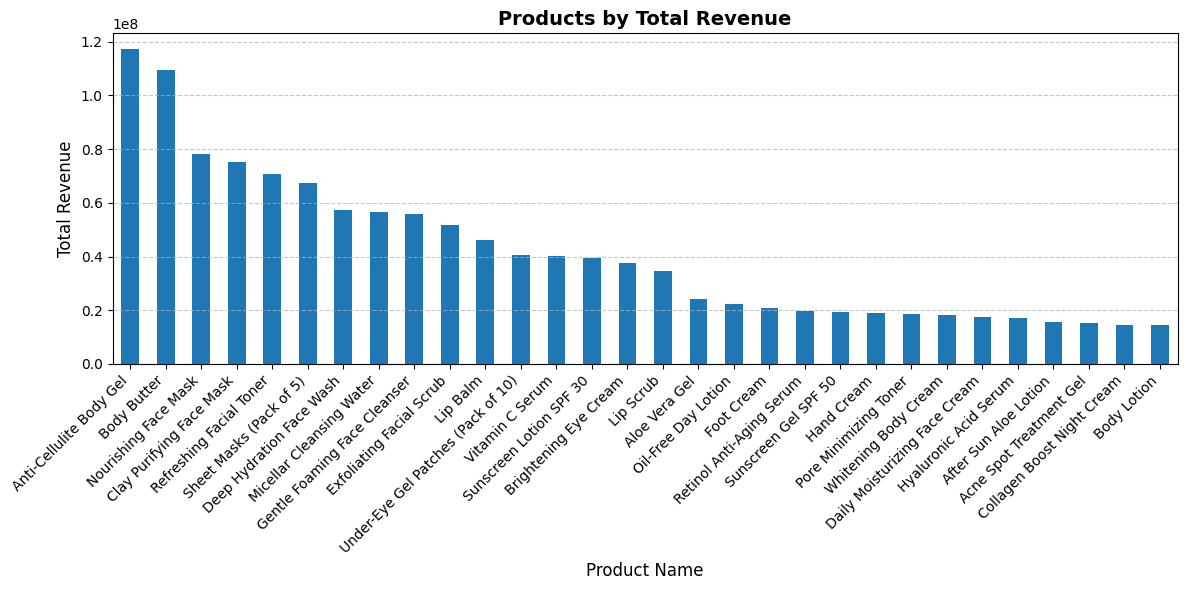

In [ ]:
# Group by product and sum revenue
product_revenue = df.groupby('product_name')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
product_revenue.plot(kind='bar')

plt.title('Products by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Bottom 10 Products**

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

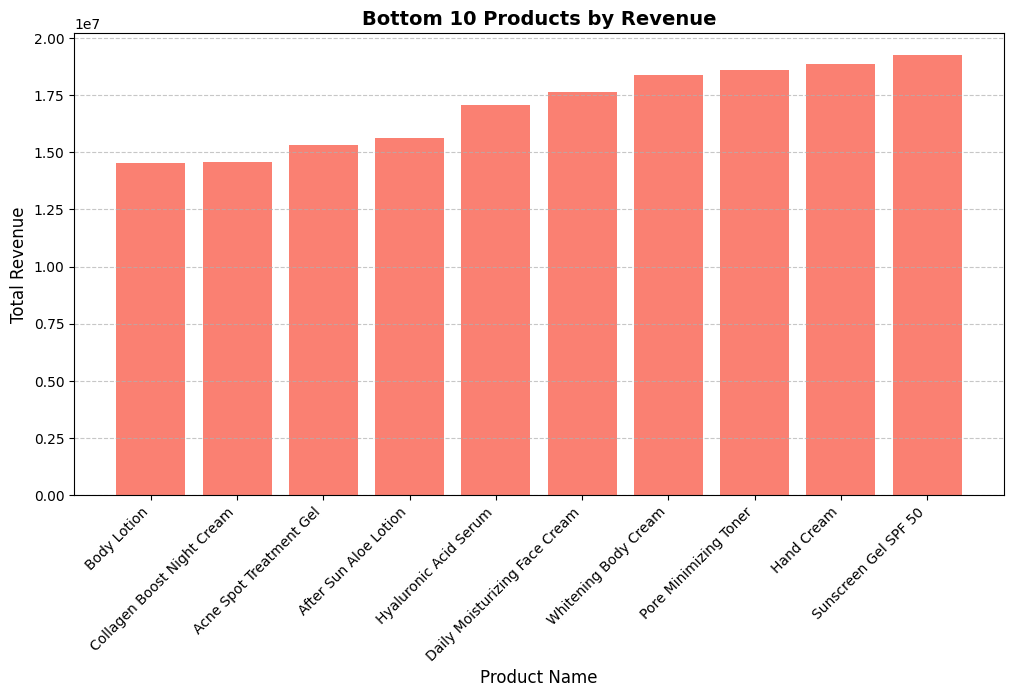

In [ ]:
# Group by product and sum revenue
bottom10 = (
    df.groupby('product_name', as_index=False)['revenue']
      .sum()
      .sort_values('revenue')  # Ascending for bottom
      .head(10)
)

# Plot
plt.figure(figsize=(12,6))
plt.bar(bottom10['product_name'], bottom10['revenue'], color='salmon')

plt.title('Bottom 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout

In [ ]:
import pandas as pd

# Assuming your dataframe is named df and has columns 'product_name' and 'revenue'
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Group by product, sum the revenue, and sort ascending (lowest first)
bottom_products = (
    df.groupby('product_name', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=True)
      .head(10)
)

# Format revenue nicely
bottom_products['revenue'] = bottom_products['revenue'].map('${:,.2f}'.format)

# Rename columns for clarity
bottom_products = bottom_products.rename(columns={
    'product_name': 'Product Name',
    'revenue': 'Total Revenue'
})

# Display as a table
print("📉 Bottom 10 Products by Revenue")
print(bottom_products.to_string(index=False))
bottom_products.to_html('bottom_10_products.html', index=False)


📉 Bottom 10 Products by Revenue
                 Product Name  Total Revenue
                  Body Lotion $14,555,053.20
   Collagen Boost Night Cream $14,598,630.00
      Acne Spot Treatment Gel $15,311,014.20
        After Sun Aloe Lotion $15,638,202.00
        Hyaluronic Acid Serum $17,058,267.00
Daily Moisturizing Face Cream $17,660,583.60
         Whitening Body Cream $18,377,791.80
        Pore Minimizing Toner $18,590,168.40
                   Hand Cream $18,856,855.20
         Sunscreen Gel SPF 50 $19,246,875.60


**Top 10 customers**

**Bottom 10 Customers**


Bottom 10 Customers by Total Revenue:
    customer_names    revenue
174            nan    18592.5
17    BB17 Company  4034673.0
163      Yodoo Ltd  4372755.0
84      Mycone Ltd  4534238.4
155   Voonyx Group  4670918.4
117   SEINDNI Corp  4760162.4
49      Epic Group  4807960.2
103      Quaxo Ltd  5026206.0
16     Aveda Group  5037100.2
167   Zoomdog Corp  5047914.0


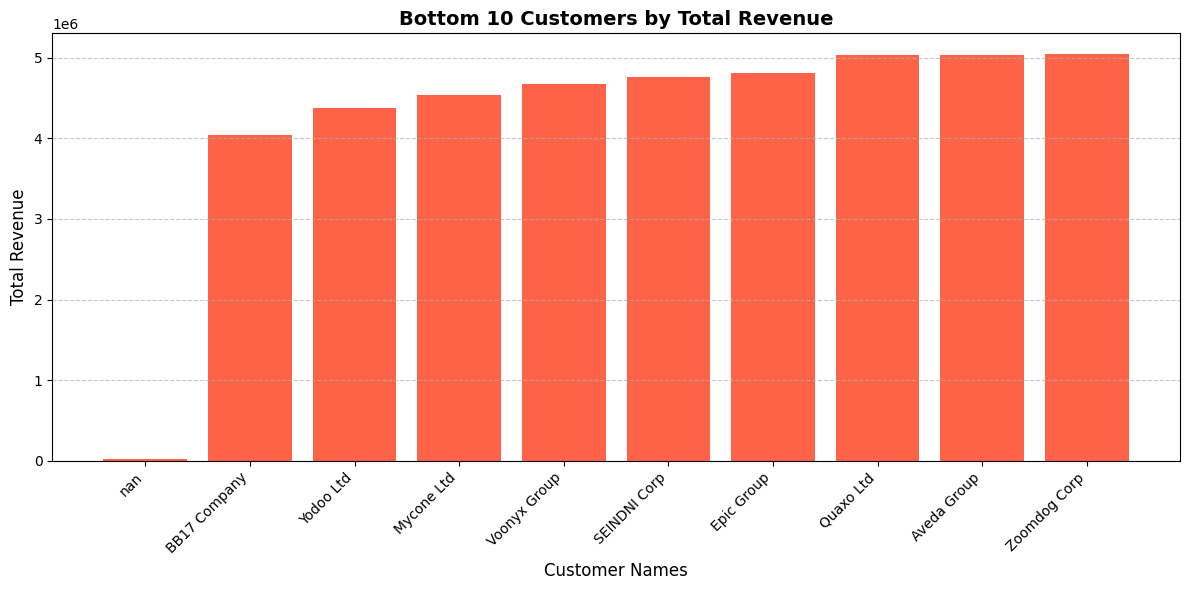

In [ ]:
# Group by customer and sum revenue
bottom10_customers = (
    df.groupby('customer_names', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=True)  # Ascending for bottom 10
      .head(10)
)

# Display the bottom 10 customers in the console
print("Bottom 10 Customers by Total Revenue:")
print(bottom10_customers)

# Plot the data
plt.figure(figsize=(12,6))
plt.bar(bottom10_customers['customer_names'], bottom10_customers['revenue'], color='tomato')

plt.title('Bottom 10 Customers by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Customer Names', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

df.columns


In [ ]:
df.columns

Index(['order_number', 'order_date', 'channel', 'customer_names',
       'warehouse_code ', 'order_quantity', 'product_name', 'unit_price',
       'revenue', 'total_unit_cost', 'state_code', 'county', 'state', 'region',
       'latitude', 'longitude', 'area_code', 'type', 'time_zone', 'budgets',
       'total_cost', 'profit', 'profit_margin_pct', 'order_month', 'year',
       'month', 'profit_margin'],
      dtype='object')

*Monthly Sales Trend (All Years Combined)*

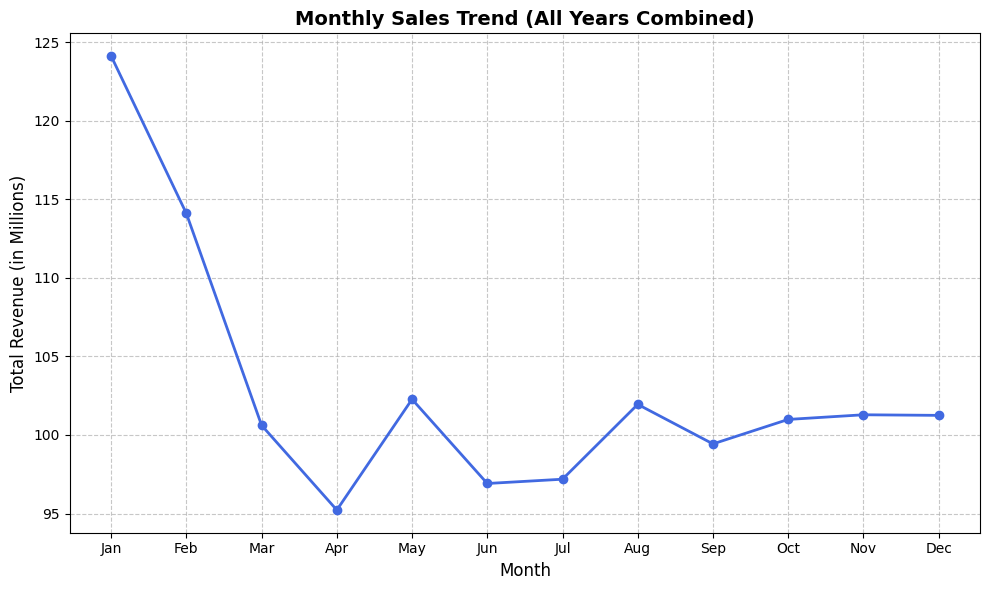

In [ ]:
# Extract month name and number for sorting
df['month_num'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')

# Group total revenue by month (across all years)
monthly_sales_all = (
    df.groupby(['month_num', 'month_name'])['revenue']
      .sum()
      .reset_index()
      .sort_values('month_num')
)

# Plot
plt.figure(figsize=(10,6))
plt.plot(monthly_sales_all['month_name'], monthly_sales_all['revenue']/1e6,
         marker='o', color='royalblue', linewidth=2)

plt.title('Monthly Sales Trend (All Years Combined)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (in Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


*Top 10 Products by Avg Profit Margin*

/tmp/ipython-input-594120636.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




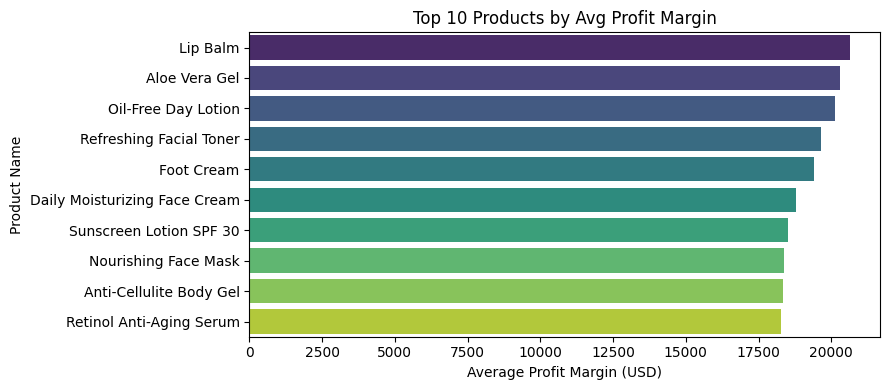

In [ ]:
top_margin = (
    df.groupby('product_name')['profit']
      .mean()                        # Calculate mean profit for each product
      .sort_values(ascending=False)  # Sort from highest to lowest average profit
      .head(10)                      # Keep only the top 10 products
)

#  Set the figure size for clarity
plt.figure(figsize=(9, 4))

# Plot a horizontal bar chart
sns.barplot(
    x=top_margin.values,    # X-axis: average profit values
    y=top_margin.index,     # Y-axis: product names
    palette='viridis'       # Color palette for the bars
)

#  Add title and axis labels
plt.title('Top 10 Products by Avg Profit Margin')  # Chart title
plt.xlabel('Average Profit Margin (USD)')          # X-axis label
plt.ylabel('Product Name')                         # Y-axis label

#  Adjust layout to prevent clipping and show the plot
plt.tight_layout()
plt.show()

Average Order Value (AOV) Distribution

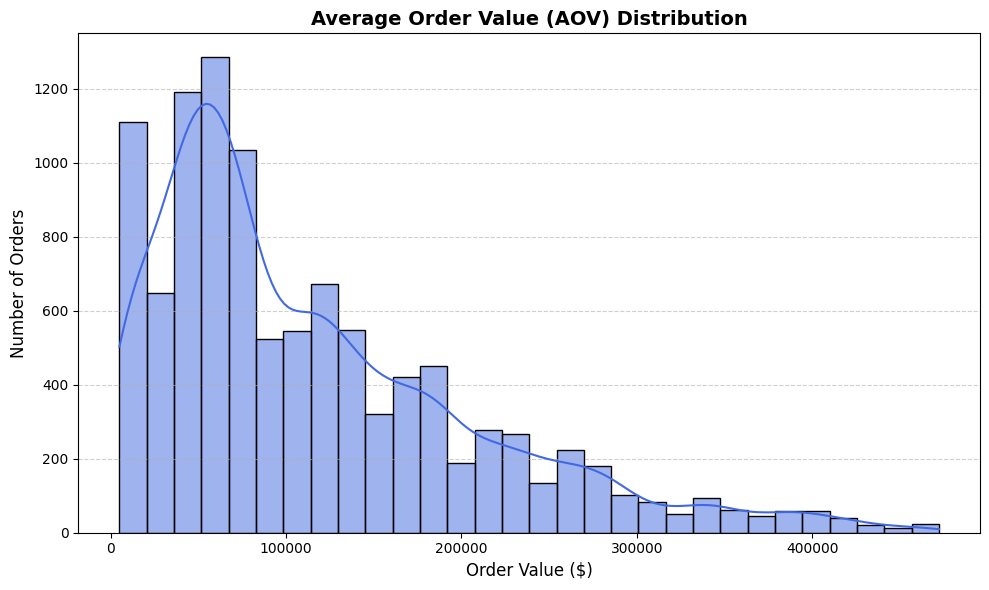

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure data types are correct
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['order_number'] = df['order_number'].astype(str)

# Step 1: Calculate AOV per order
order_aov = (
    df.groupby('order_number', as_index=False)['revenue']
      .sum()
      .rename(columns={'revenue': 'order_value'})
)

# Step 2: Plot histogram / distribution
plt.figure(figsize=(10,6))
sns.histplot(order_aov['order_value'], bins=30, kde=True, color='royalblue')

plt.title('Average Order Value (AOV) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Order Value ($)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Profit Margin % vs. Unit Price

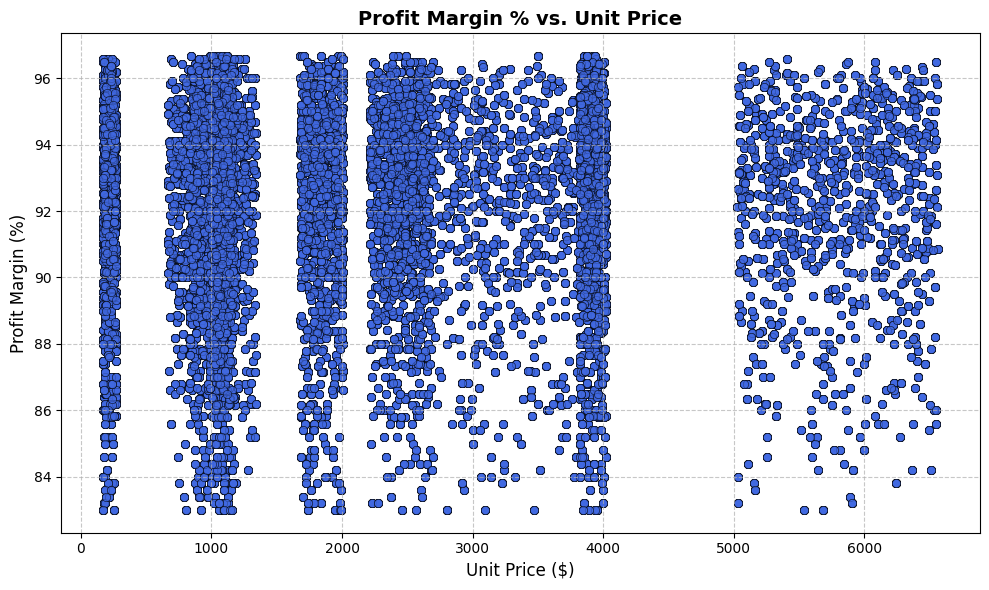

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure numeric types
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['total_unit_cost'] = pd.to_numeric(df['total_unit_cost'], errors='coerce')

# Calculate profit and profit margin %
df['profit'] = df['revenue'] - df['total_unit_cost']
df['profit_margin'] = (df['profit'] / df['revenue']) * 100

# Remove invalid or infinite values
df = df.replace([float('inf'), -float('inf')], pd.NA).dropna(subset=['profit_margin', 'unit_price'])

# Scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='unit_price', y='profit_margin',
                alpha=0.7, color='royalblue', edgecolor='black')

plt.title('Profit Margin % vs. Unit Price', fontsize=14, fontweight='bold')
plt.xlabel('Unit Price ($)', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Unit Price Distribution per Product


/tmp/ipython-input-2684278958.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




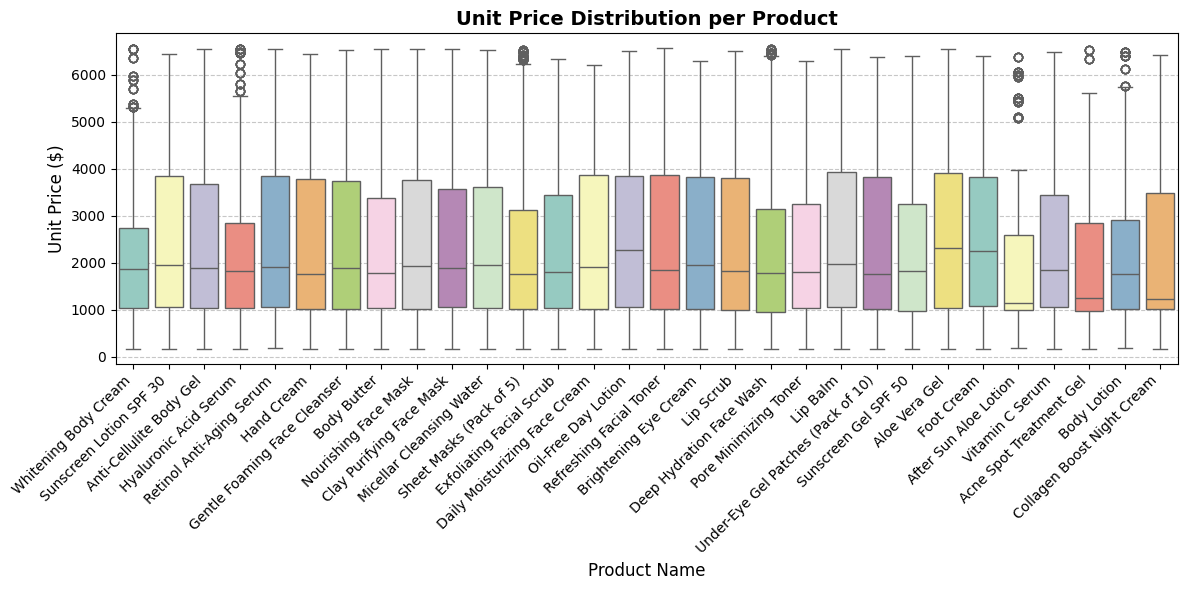

In [ ]:


# Optional: Filter top products by sales or revenue to make the chart readable
top_products = (
    df.groupby('product_name')['revenue']
      .sum()
      .sort_values(ascending=False)

      .index
)
df_top = df[df['product_name'].isin(top_products)]

# Plot boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='product_name', y='unit_price', palette='Set3')

plt.title('Unit Price Distribution per Product', fontsize=14, fontweight='bold')
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Unit Price ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 10 States by Revenue and Order Count

/tmp/ipython-input-366585003.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-366585003.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




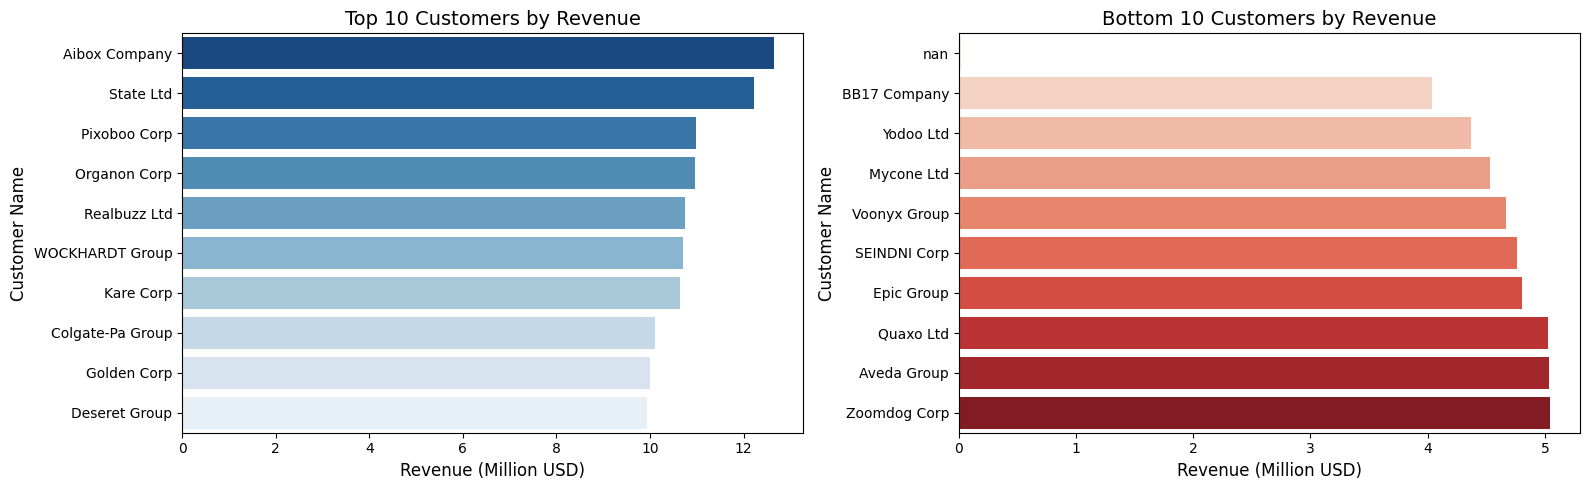

In [ ]:
top_rev = (
    df.groupby('customer_names')['revenue']
      .sum()                        # Sum revenue for each customer
      .sort_values(ascending=False) # Sort from highest to lowest
      .head(10)                     # Keep top 10 customers
)

#  Calculate total revenue per customer and select bottom 10
bottom_rev = (
    df.groupby('customer_names')['revenue']
      .sum()                        # Sum revenue for each customer
      .sort_values(ascending=True)  # Sort from lowest to highest
      .head(10)                     # Keep bottom 10 customers
)

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Top 10 customers by revenue (converted to millions)
sns.barplot(
    x=top_rev.values / 1e6,    # X-axis: revenue in millions
    y=top_rev.index,           # Y-axis: customer names
    palette='Blues_r',         # Color palette (reversed blues)
    ax=axes[0]                 # Draw on the left subplot
)
axes[0].set_title('Top 10 Customers by Revenue', fontsize=14)         # Title
axes[0].set_xlabel('Revenue (Million USD)', fontsize=12)              # X-axis label
axes[0].set_ylabel('Customer Name', fontsize=12)                      # Y-axis label

# Plot 2: Bottom 10 customers by revenue (converted to millions)
sns.barplot(
    x=bottom_rev.values / 1e6, # X-axis: revenue in millions
    y=bottom_rev.index,        # Y-axis: customer names
    palette='Reds',            # Color palette (reds)
    ax=axes[1]                 # Draw on the right subplot
)
axes[1].set_title('Bottom 10 Customers by Revenue', fontsize=14)      # Title
axes[1].set_xlabel('Revenue (Million USD)', fontsize=12)              # X-axis label
axes[1].set_ylabel('Customer Name', fontsize=12)                      # Y-axis label

# Adjust layout to prevent overlap and display both charts
plt.tight_layout()
plt.show()

Average Profit Margin by Channel

/tmp/ipython-input-15237516.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




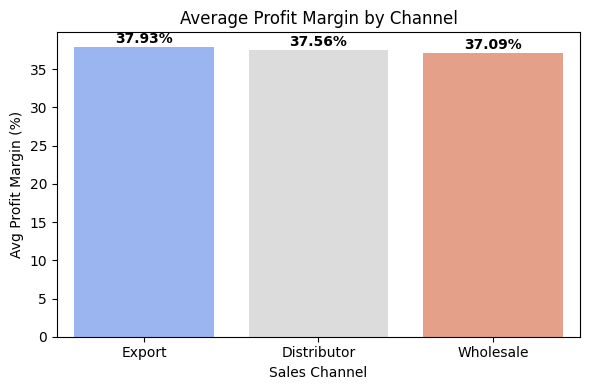

In [ ]:
# 1️⃣ Compute average profit margin percentage for each channel
channel_margin = (
    df.groupby('channel')['profit_margin_pct']  # Group by sales channel
      .mean()                                  # Calculate mean profit margin %
      .sort_values(ascending=False)            # Sort channels from highest to lowest margin
)

# 2️⃣ Set the figure size for clarity
plt.figure(figsize=(6, 4))

# 3️⃣ Plot a bar chart of average profit margin by channel
ax = sns.barplot(
    x=channel_margin.index,    # X-axis: channel names
    y=channel_margin.values,   # Y-axis: average profit margin values
    palette='coolwarm'         # Color palette for bars
)

# 4️⃣ Add chart title and axis labels
plt.title('Average Profit Margin by Channel')  # Main title
plt.xlabel('Sales Channel')                    # X-axis label
plt.ylabel('Avg Profit Margin (%)')             # Y-axis label

# 5️⃣ Annotate each bar with its exact margin percentage
for i, v in enumerate(channel_margin.values):
    ax.text(
        i,                  # X position (bar index)
        v + 0.5,            # Y position (bar height + small offset)
        f"{v:.2f}%",        # Text label showing percentage with two decimals
        ha='center',        # Center-align the text horizontally
        fontweight='bold'   # Bold font for readability
    )

# 6️⃣ Adjust layout to prevent clipping and display the plot
plt.tight_layout()
plt.show()

Top and Bottom 10 Customers by Revenue

/tmp/ipython-input-3529223103.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




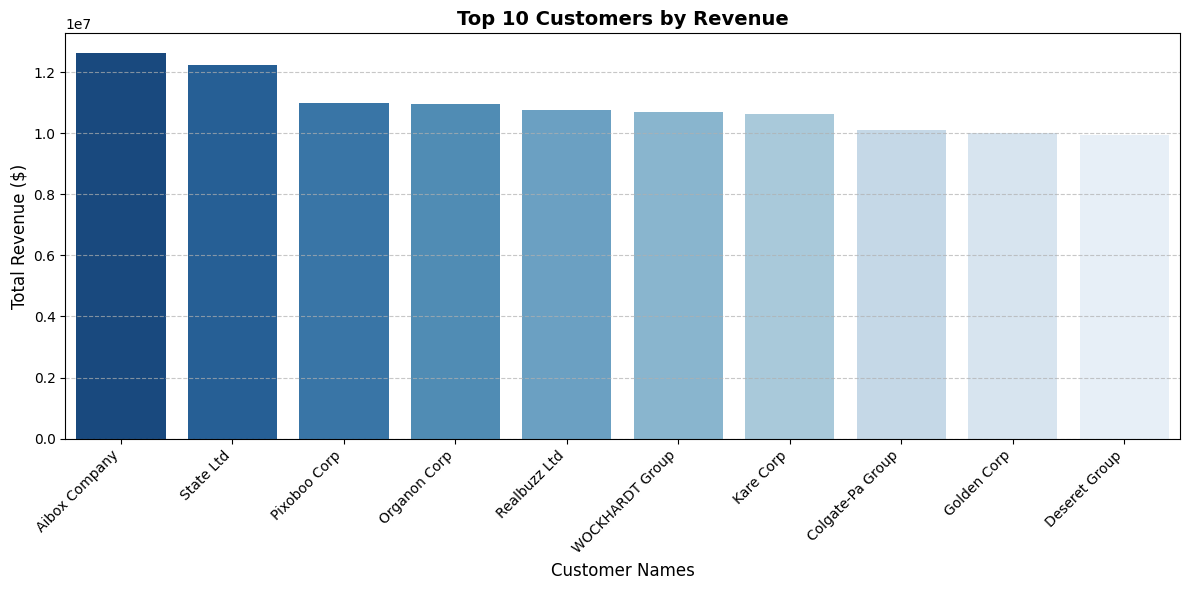

/tmp/ipython-input-3529223103.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




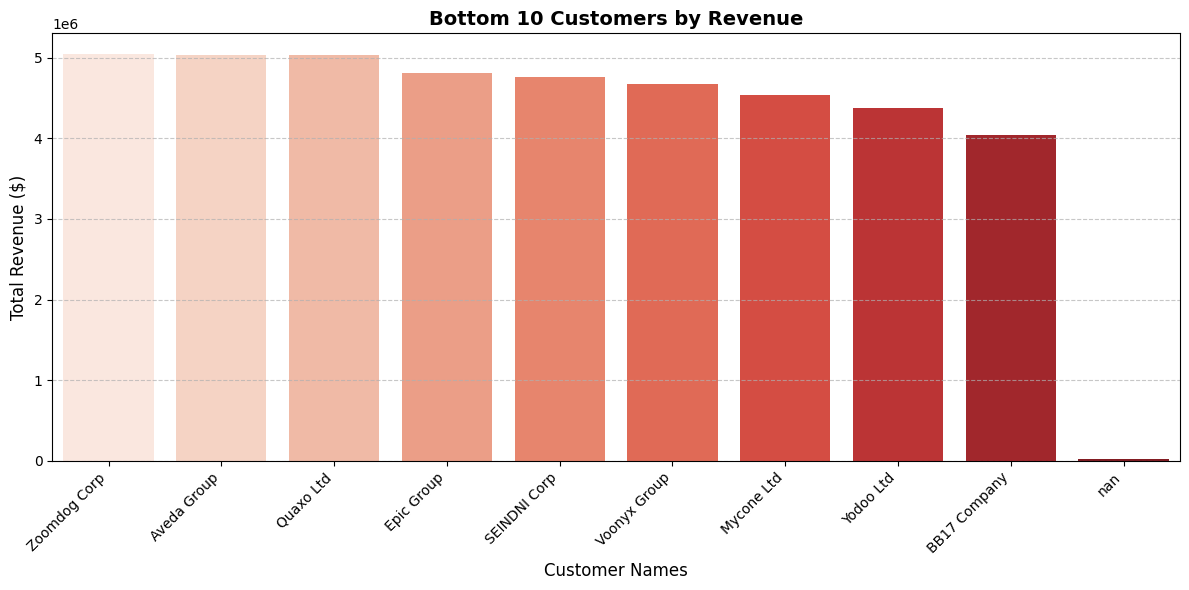

In [ ]:
# Ensure revenue is numeric
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Group by customer to get total revenue
customer_revenue = (
    df.groupby('customer_names', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

# Split Top 10 and Bottom 10
top10_customers = customer_revenue.head(10)
bottom10_customers = customer_revenue.tail(10)

# --- Plot: Top 10 Customers ---
plt.figure(figsize=(12,6))
sns.barplot(data=top10_customers, x='customer_names', y='revenue', palette='Blues_r')
plt.title('Top 10 Customers by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Customer Names', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plot: Bottom 10 Customers ---
plt.figure(figsize=(12,6))
sns.barplot(data=bottom10_customers, x='customer_names', y='revenue', palette='Reds')
plt.title('Bottom 10 Customers by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Customer Names', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Customer Segmentation: Revenue vs. Profit Margin

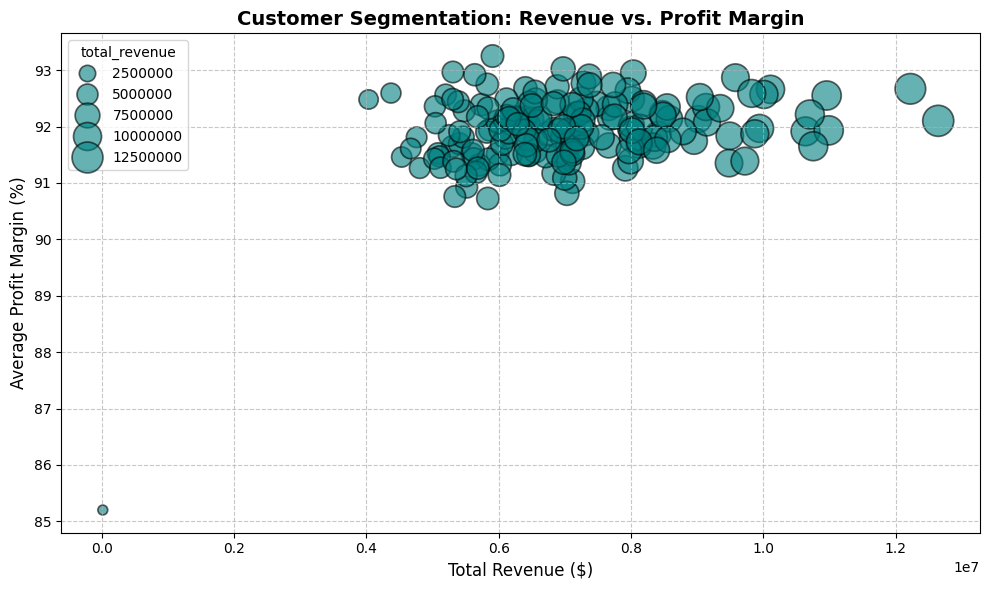

In [ ]:

# Ensure numeric columns
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['total_unit_cost'] = pd.to_numeric(df['total_unit_cost'], errors='coerce')

# Calculate profit and profit margin
df['profit'] = df['revenue'] - df['total_unit_cost']
df['profit_margin'] = (df['profit'] / df['revenue']) * 100

# Aggregate by customer: total revenue and average profit margin
customer_seg = (
    df.groupby('customer_names', as_index=False)
      .agg(total_revenue=('revenue', 'sum'),
           avg_profit_margin=('profit_margin', 'mean'))
)

# Scatter plot (Revenue vs Profit Margin)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=customer_seg,
    x='total_revenue', y='avg_profit_margin',
    size='total_revenue', sizes=(50, 500),
    alpha=0.6, color='teal', edgecolor='black'
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Average Profit Margin (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Correlation Heatmap of Numeric Features

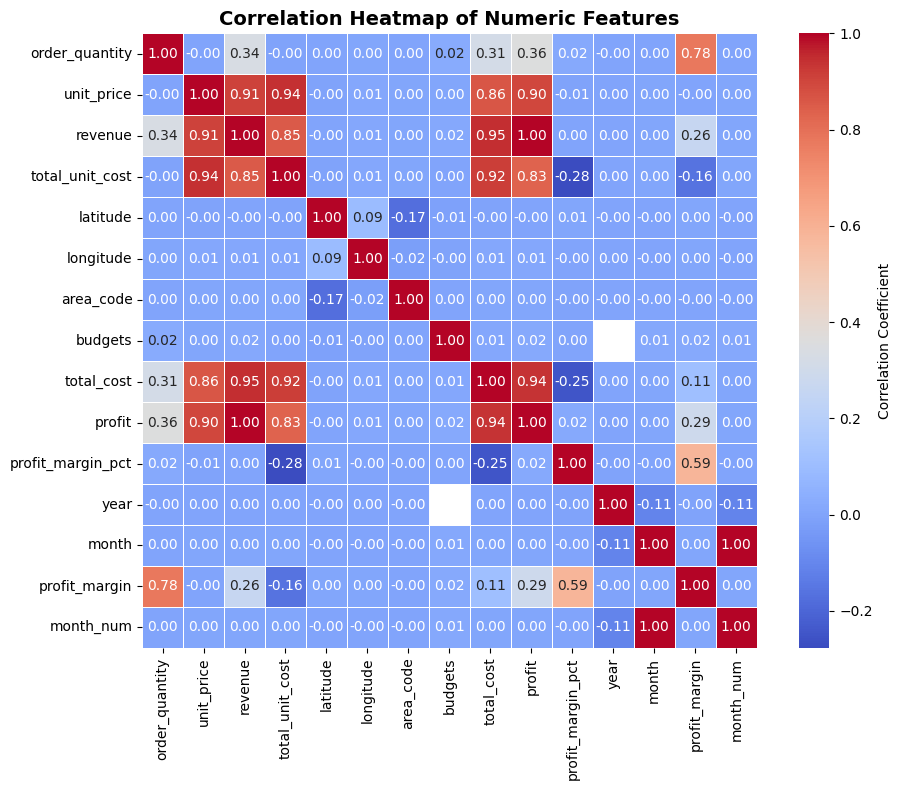

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number']).copy()

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation coefficients
    fmt=".2f",           # 2 decimal places
    cmap='coolwarm',     # Color scheme (red = positive, blue = negative)
    linewidths=0.5,      # Line thickness between cells
    square=True,         # Make cells square
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# --- 0) Basic hygiene ---
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['order_quantity'] = pd.to_numeric(df['order_quantity'], errors='coerce')
df['unit_price'] = pd.to_numeric(df.get('unit_price', np.nan), errors='coerce')  # optional

# Month key for growth calc
df['order_month'] = df['order_date'].dt.to_period('M')

# --- 1) Core per-product KPIs ---
kpi_core = (
    df.groupby('product_name', as_index=False)
      .agg(total_revenue=('revenue','sum'),
           units_sold=('order_quantity','sum'),
           total_orders=('order_number','nunique'),
           unit_price_median=('unit_price','median'))            # optional, nice to have
)

# Average Order Value
kpi_core['avg_order_value'] = (
    kpi_core['total_revenue'] / kpi_core['total_orders'].replace({0: np.nan})
)

# --- 2) Top Region per product (by revenue) ---
prod_region = (
    df.groupby(['product_name','region'], as_index=False)['revenue']
      .sum()
      .rename(columns={'revenue':'region_revenue'})
)

# argmax per product to find the top region
idx = prod_region.groupby('product_name')['region_revenue'].idxmax()
top_region = prod_region.loc[idx, ['product_name','region']].rename(columns={'region':'top_region'})

# --- 3) Month-over-Month growth % (latest two months for each product) ---
monthly = (
    df.groupby(['product_name','order_month'], as_index=False)['revenue']
      .sum()
      .sort_values(['product_name','order_month'])
)

def last_two_mom_pct(g):
    # g is rows for one product, already sorted by month
    if len(g) < 2:
        return pd.Series({'mom_growth_pct': np.nan})
    last = g.iloc[-1]['revenue']
    prev = g.iloc[-2]['revenue']
    if prev == 0 or pd.isna(prev):
        return pd.Series({'mom_growth_pct': np.nan})
    return pd.Series({'mom_growth_pct': (last - prev) / prev * 100.0})

mom = monthly.groupby('product_name').apply(last_two_mom_pct).reset_index()

# --- 4) Assemble final table ---
product_kpis = (
    kpi_core
    .merge(top_region, on='product_name', how='left')
    .merge(mom, on='product_name', how='left')
    .sort_values('total_revenue', ascending=False)
)

# Nice formatting columns (optional views)
product_kpis_view = product_kpis.copy()
for col in ['total_revenue','avg_order_value']:
    product_kpis_view[col] = product_kpis_view[col].round(2)
product_kpis_view['mom_growth_pct'] = product_kpis_view['mom_growth_pct'].round(1)

# Show the top 20 products by revenue
print(product_kpis_view)

# --- 5) Export for your UI/cards/dashboard ---
product_kpis_view.to_csv('product_kpis.csv', index=False)


                          product_name  total_revenue  units_sold  \
3              Anti-Cellulite Body Gel    117291821.4       50364   
4                          Body Butter    109473966.6       50358   
19                Nourishing Face Mask     78281379.6       34014   
7             Clay Purifying Face Mask     75390396.6       32484   
22             Refreshing Facial Toner     70804380.6       28692   
24             Sheet Masks (Pack of 5)     67331623.2       31242   
10            Deep Hydration Face Wash     57401097.6       26304   
18            Micellar Cleansing Water     56701537.2       24072   
13        Gentle Foaming Face Cleanser     55952289.6       24138   
11            Exfoliating Facial Scrub     51764816.4       23748   
16                            Lip Balm     46228954.8       17754   
27  Under-Eye Gel Patches (Pack of 10)     40594442.4       17682   
28                     Vitamin C Serum     40149147.0       17892   
26             Sunscreen Lotion SP

/tmp/ipython-input-3507530330.py:55: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
import pandas as pd

# Ensure 'revenue' column is numeric
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Group revenue by state
state_performance = (
    df.groupby('state', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

# ----- TOP 10 STATES -----
top_10_states = state_performance.head(10).copy()
top_10_states['revenue'] = top_10_states['revenue'].map('${:,.2f}'.format)
top_10_states = top_10_states.rename(columns={'state': 'State', 'revenue': 'Total Revenue'})

print("📈 Top 10 Performing States by Revenue")
print(top_10_states.to_string(index=False))

# ----- BOTTOM 10 STATES -----
bottom_10_states = state_performance.tail(10).copy()
bottom_10_states['revenue'] = bottom_10_states['revenue'].map('${:,.2f}'.format)
bottom_10_states = bottom_10_states.rename(columns={'state': 'State', 'revenue': 'Total Revenue'})

print("\n📉 Bottom 10 Performing States by Revenue")
print(bottom_10_states.to_string(index=False))


📈 Top 10 Performing States by Revenue
        State   Total Revenue
   California $228,785,436.00
     Illinois $111,050,965.70
      Florida  $90,204,679.50
        Texas  $84,011,903.00
     New York  $55,534,960.00
      Indiana  $54,601,690.20
   New Jersey  $46,830,956.50
  Connecticut  $44,251,228.70
     Michigan  $39,025,315.80
Massachusetts  $35,011,942.10

📉 Bottom 10 Performing States by Revenue
               State Total Revenue
        North Dakota $3,939,981.90
        Rhode Island $3,562,410.10
             Montana $3,415,070.40
         Mississippi $3,399,265.10
       New Hampshire $2,382,365.90
             Wyoming $1,769,825.10
        South Dakota $1,681,224.30
District of Columbia $1,674,859.30
               Maine $1,567,284.10
            Delaware $1,248,591.90


In [ ]:
import pandas as pd

# Ensure 'revenue' is numeric
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Group by customer and sum their total revenue
top_customers = (
    df.groupby('customer_names', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
      .head(10)
)
bottom_customers = (
    df.groupby('customer_names', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=True)
      .head(10)
)

# Format revenue as currency
top_customers['revenue'] = top_customers['revenue'].map('${:,.2f}'.format)
bottom_customers['revenue'] = bottom_customers['revenue'].map('${:,.2f}'.format)

# Rename columns for readability
top_customers = top_customers.rename(columns={
    'customer_names': 'Customer Name',
    'revenue': 'Total Revenue'
})
bottom_customers = bottom_customers.rename(columns={
    'customer_names': 'Customer Name',
    'revenue': 'Total Revenue'
})

# Display the table
print("📊 Top 10 Customers by Revenue")
print(top_customers.to_string(index=False))

print("\n📈 Bottom 10 Customers by Revenue")
print(bottom_customers.to_string(index=False))

📊 Top 10 Customers by Revenue
   Customer Name  Total Revenue
   Aibox Company $12,641,251.80
       State Ltd $12,220,639.20
    Pixoboo Corp $10,986,459.00
    Organon Corp $10,955,826.60
    Realbuzz Ltd $10,753,299.00
 WOCKHARDT Group $10,701,963.60
       Kare Corp $10,635,633.60
Colgate-Pa Group $10,107,003.60
     Golden Corp $10,007,669.40
   Deseret Group  $9,942,223.80

📈 Bottom 10 Customers by Revenue
Customer Name Total Revenue
          nan    $18,592.50
 BB17 Company $4,034,673.00
    Yodoo Ltd $4,372,755.00
   Mycone Ltd $4,534,238.40
 Voonyx Group $4,670,918.40
 SEINDNI Corp $4,760,162.40
   Epic Group $4,807,960.20
    Quaxo Ltd $5,026,206.00
  Aveda Group $5,037,100.20
 Zoomdog Corp $5,047,914.00
